## Imports


In [ ]:
import pandas as pd
import numpy as np
from itertools import product
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [ ]:
# Connection with Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Configure outputs
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

In [ ]:
info_dict = {
    "ID": "Номер записи",
    "shop_id": "Порядковый номер магазина",
    "item_id": "Порядковый номер товара",
    "item_category_id": "Порядковый номер категории",
    "item_cnt_day": "Продано за день",
    "item_price": "Цена товрара",
    "date": "Дата продажи yyyy-mm-dd",
    "date_block_num": "Порядковый номер месяца, используемый для удобства",
    "item_name": "Название товара",
    "shop_name": "Название магазина",
    "item_category_name": "Название категории товара",
}

In [ ]:
def descr_features(df):
    # Exclude ids
    cols = df.columns.drop(["shop_id", "item_id"])
    data = df[cols].copy()

    # Data types
    features = data.dtypes.to_frame(name="data_type")

    # Text description from info_dict
    features["meaning"] = [info_dict.get(x, "new") for x in features.index]

    # Number and percent of missing data
    features["n_NaN"] = data.isna().sum()
    features["%NaN"] = round(features["n_NaN"] / len(data) * 100, 2)

    # Number of unique values
    features["nunique"] = data.nunique().values

    # describe() info
    describe_train = data.describe(include="all").round(1).T
    features = pd.merge(
        features,
        describe_train.round(0),
        how="left",
        left_index=True,
        right_index=True
    )

    return features

## Data loading

In [ ]:
# Load train
train = pd.read_csv("/content/drive/MyDrive/ds-practice/data/train.csv")
train.head(10)

,date,date_block_num,shop_id,item_id,item_price,item_cnt_day,day,month,year
0,2013-01-02,0,59,22154,999.00,1,2,1,2013
1,2013-01-03,0,25,2552,899.00,1,3,1,2013
2,2013-01-05,0,25,2552,899.00,-1,5,1,2013
3,2013-01-06,0,25,2554,1709.05,1,6,1,2013
4,2013-01-15,0,25,2555,1099.00,1,15,1,2013
5,2013-01-10,0,25,2564,349.00,1,10,1,2013
6,2013-01-02,0,25,2565,549.00,1,2,1,2013
7,2013-01-04,0,25,2572,239.00,1,4,1,2013
8,2013-01-11,0,25,2572,299.00,1,11,1,2013
9,2013-01-03,0,25,2573,299.00,3,3,1,2013


In [ ]:
# Load test
test = pd.read_csv("/content/drive/MyDrive/ds-practice/data/test.csv")
test.head()

,shop_id,item_id
0,5,5037
1,5,5320
2,5,5233
3,5,5232
4,5,5268


In [ ]:
# Load shops
shops = pd.read_csv("/content/drive/MyDrive/ds-practice/data/shops.csv")
shops.head()

,shop_name,shop_id
0,"!Якутск Орджоникидзе, 56 фран",0
1,"!Якутск ТЦ ""Центральный"" фран",1
2,"Адыгея ТЦ ""Мега""",2
3,"Балашиха ТРК ""Октябрь-Киномир""",3
4,"Волжский ТЦ ""Волга Молл""",4


In [ ]:
# Load items
items = pd.read_csv("/content/drive/MyDrive/ds-practice/data/items.csv")
items.head()

,item_name,item_id,item_category_id
0,! ВО ВЛАСТИ НАВАЖДЕНИЯ (ПЛАСТ.) D,0,40
1,!ABBYY FineReader 12 Professional Edition Full...,1,76
2,***В ЛУЧАХ СЛАВЫ (UNV) D,2,40
3,***ГОЛУБАЯ ВОЛНА (Univ) D,3,40
4,***КОРОБКА (СТЕКЛО) D,4,40


In [ ]:
# Merge shops and items info
train = train.merge(items, how="left", on="item_id").merge(shops, how="left", on="shop_id")
descr_features(train)

,data_type,meaning,n_NaN,%NaN,nunique,count,unique,top,freq,mean,std,min,25%,50%,75%,max
date,object,Дата продажи yyyy-mm-dd,0,0.0,1034,2935847,1034,2013-12-28,9434,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_block_num,int64,"Порядковый номер месяца, используемый для удоб...",0,0.0,34,2935847.0,NaN,NaN,NaN,14.6,9.4,0.0,7.0,14.0,23.0,33.0
item_price,float64,Цена товрара,0,0.0,19991,2935847.0,NaN,NaN,NaN,890.7,1720.5,0.1,249.0,399.0,999.0,59200.0
item_cnt_day,int64,Продано за день,0,0.0,198,2935847.0,NaN,NaN,NaN,1.2,2.6,-22.0,1.0,1.0,1.0,2169.0
day,int64,new,0,0.0,31,2935847.0,NaN,NaN,NaN,15.9,8.9,1.0,8.0,16.0,24.0,31.0
month,int64,new,0,0.0,12,2935847.0,NaN,NaN,NaN,6.2,3.5,1.0,3.0,6.0,9.0,12.0
year,int64,new,0,0.0,3,2935847.0,NaN,NaN,NaN,2013.8,0.8,2013.0,2013.0,2014.0,2014.0,2015.0
item_name,object,Название товара,0,0.0,21806,2935847,21806,Фирменный пакет майка 1С Интерес белый (34*42)...,31340,NaN,NaN,NaN,NaN,NaN,NaN,NaN
item_category_id,int64,Порядковый номер категории,0,0.0,84,2935847.0,NaN,NaN,NaN,40.0,17.1,0.0,28.0,40.0,55.0,83.0
shop_name,object,Название магазина,0,0.0,57,2935847,57,"Москва ТЦ ""Семеновский""",235636,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Data analysis

In [ ]:
# Add year-month feature
train["year_month"] = train["date"].apply(lambda x: x[:-2])

# Add revenue feature
train['revenue'] = train['item_price'] * train['item_cnt_day']

# Group sales by month
monthly_sales = train.groupby('year_month')

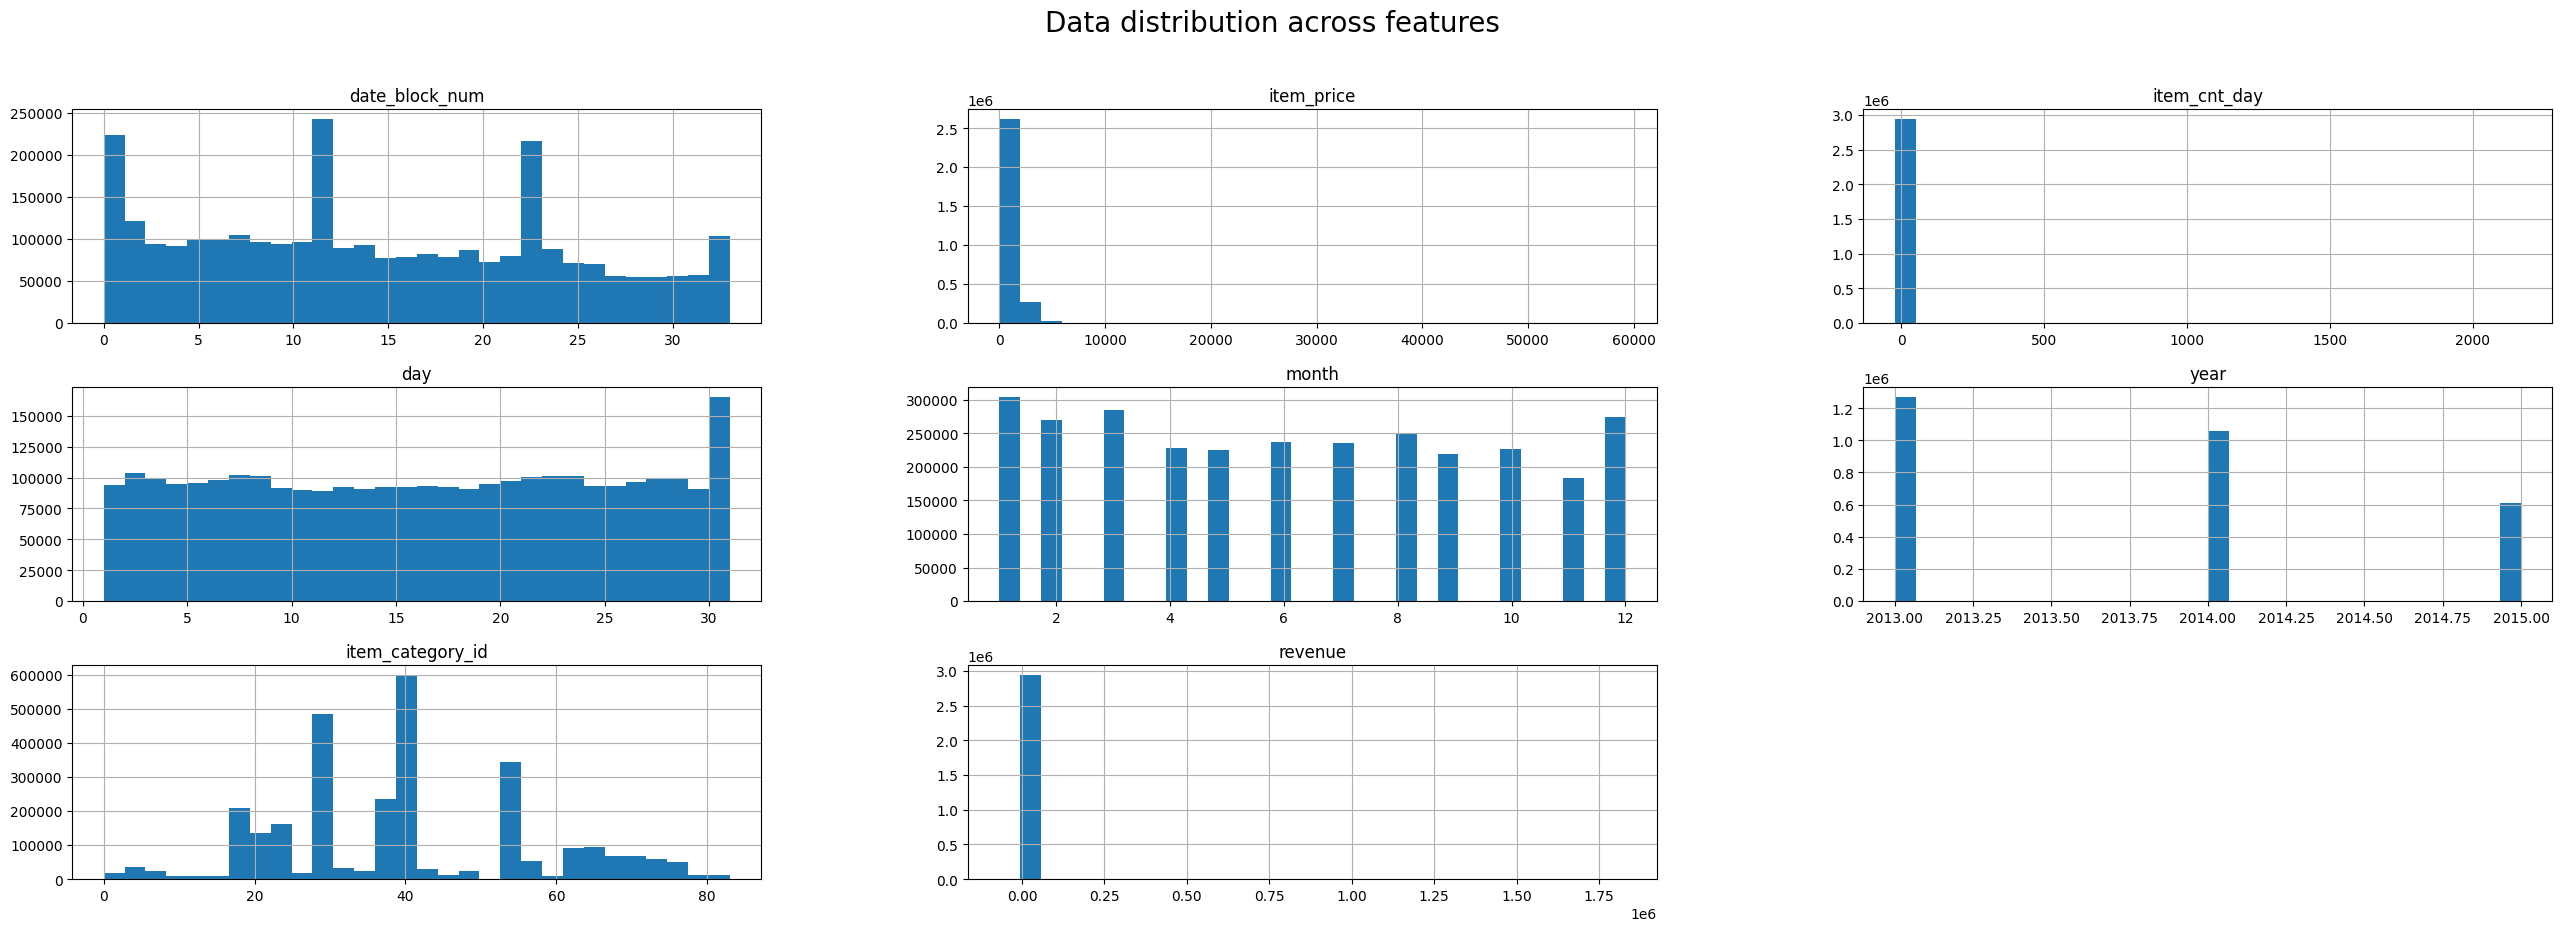

In [ ]:
# Data distribution
train.drop(columns=["item_id", "shop_id"]).hist(bins=30, figsize=(32, 10), sharex=False)
plt.suptitle("Data distribution across features", fontsize=20)

plt.show()

- Most customers tend to buy one unit per transaction, as shown in the quantity chart.
- High-priced items are rare but present, forming a long tail in the price distribution.
- Category 40 leads in sales volume, indicating strong market demand.

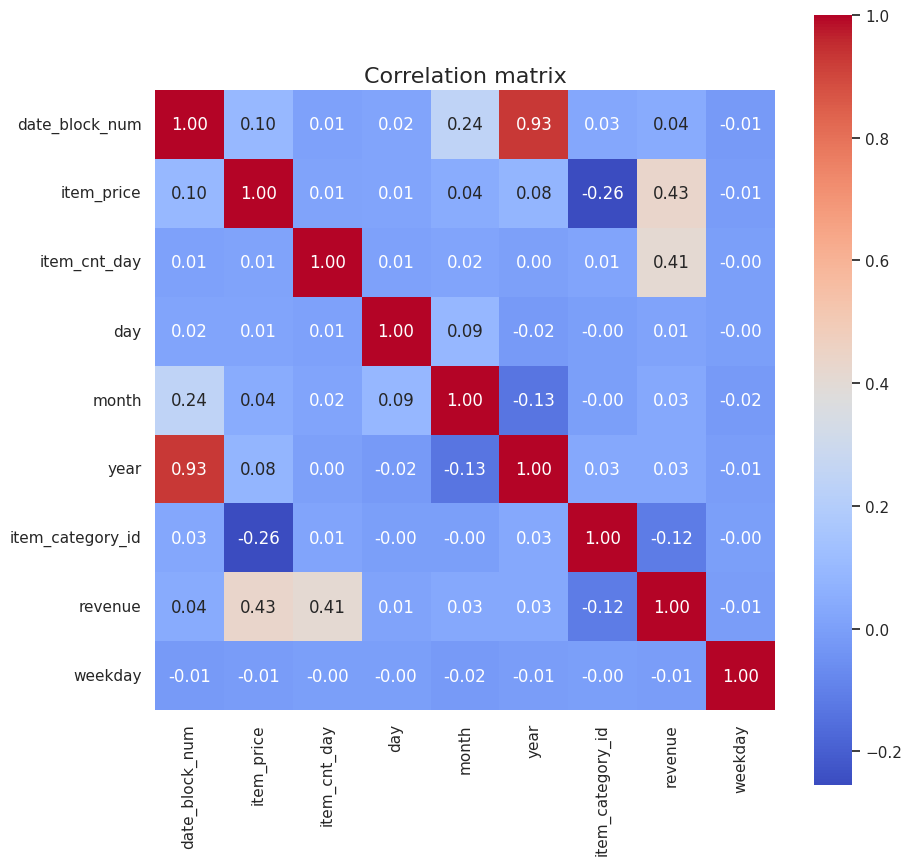

In [ ]:
# Display the correlation matrix
plt.figure(figsize=(10, 10))
plt.title("Correlation matrix", fontsize=16)
corr_matrix = train.drop(columns=["shop_id", "item_id"]).corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True);

Features show weak mutual correlation.
- The date_block_num and year_month features dublicate each other
- The revenue feature was created by multiplying item_price and item_cnt_day for visualisation purposes
- Item price depends on its category (correlation coficient in 0.26)

### Sales in time

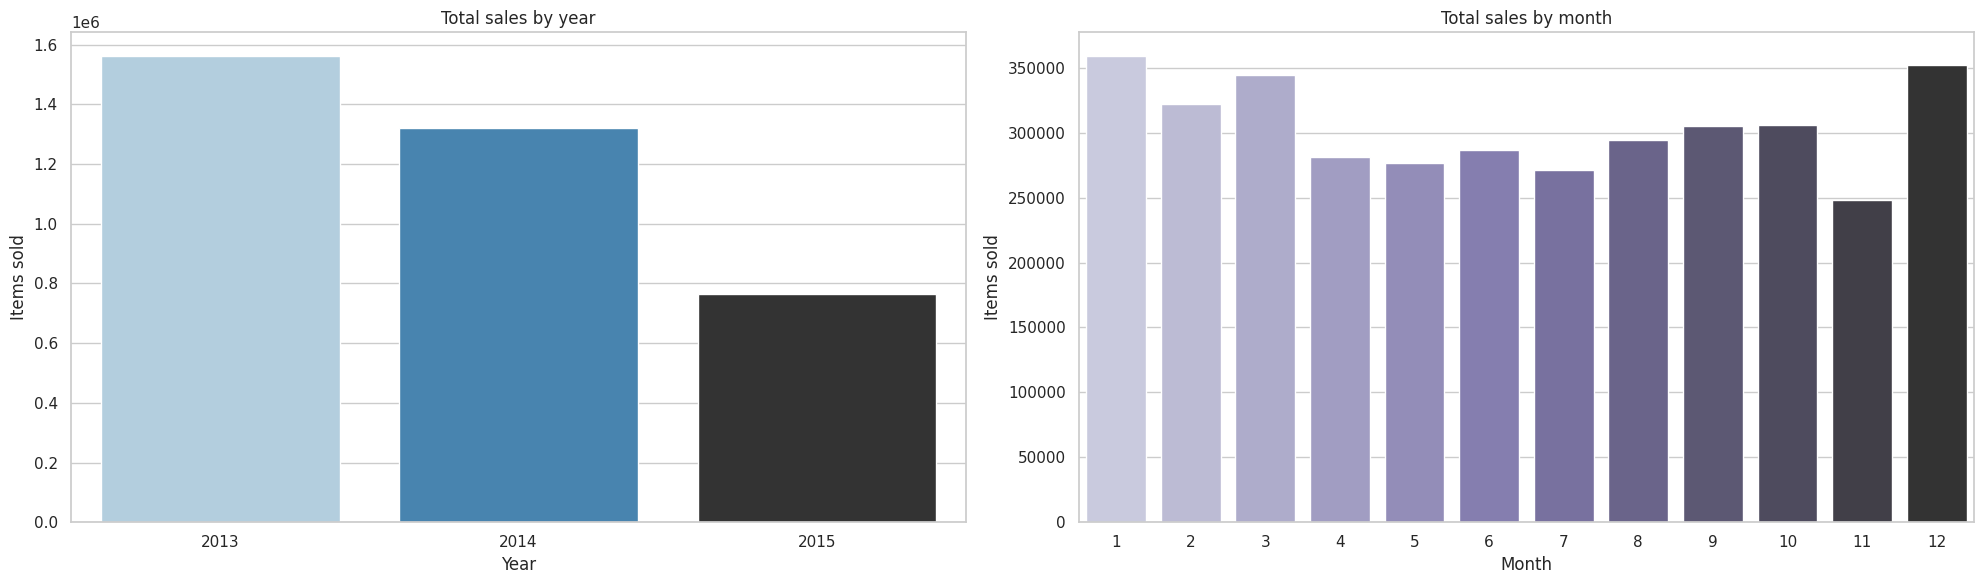

In [ ]:
# Set visualization style
sns.set(style="whitegrid")
plt.figure(figsize=(20, 6))

# Total sales by year
plt.subplot(1, 2, 1)
sales_by_year = train.groupby('year', as_index=False)['item_cnt_day'].sum()
sns.barplot(data=sales_by_year, x='year', y='item_cnt_day', hue='year', palette="Blues_d", legend=False)
plt.title("Total sales by year")
plt.xlabel("Year")
plt.ylabel("Items sold")

# Total sales by month
plt.subplot(1, 2, 2)
sales_by_month = train.groupby('month', as_index=False)['item_cnt_day'].sum()
sns.barplot(data=sales_by_month, x='month', y='item_cnt_day', hue='month', palette="Purples_d", legend=False)
plt.title("Total sales by month")
plt.xlabel("Month")
plt.ylabel("Items sold")

plt.tight_layout()

- We have less info about 2015th year
- Winter months show higher sales, likely due to product seasonality.

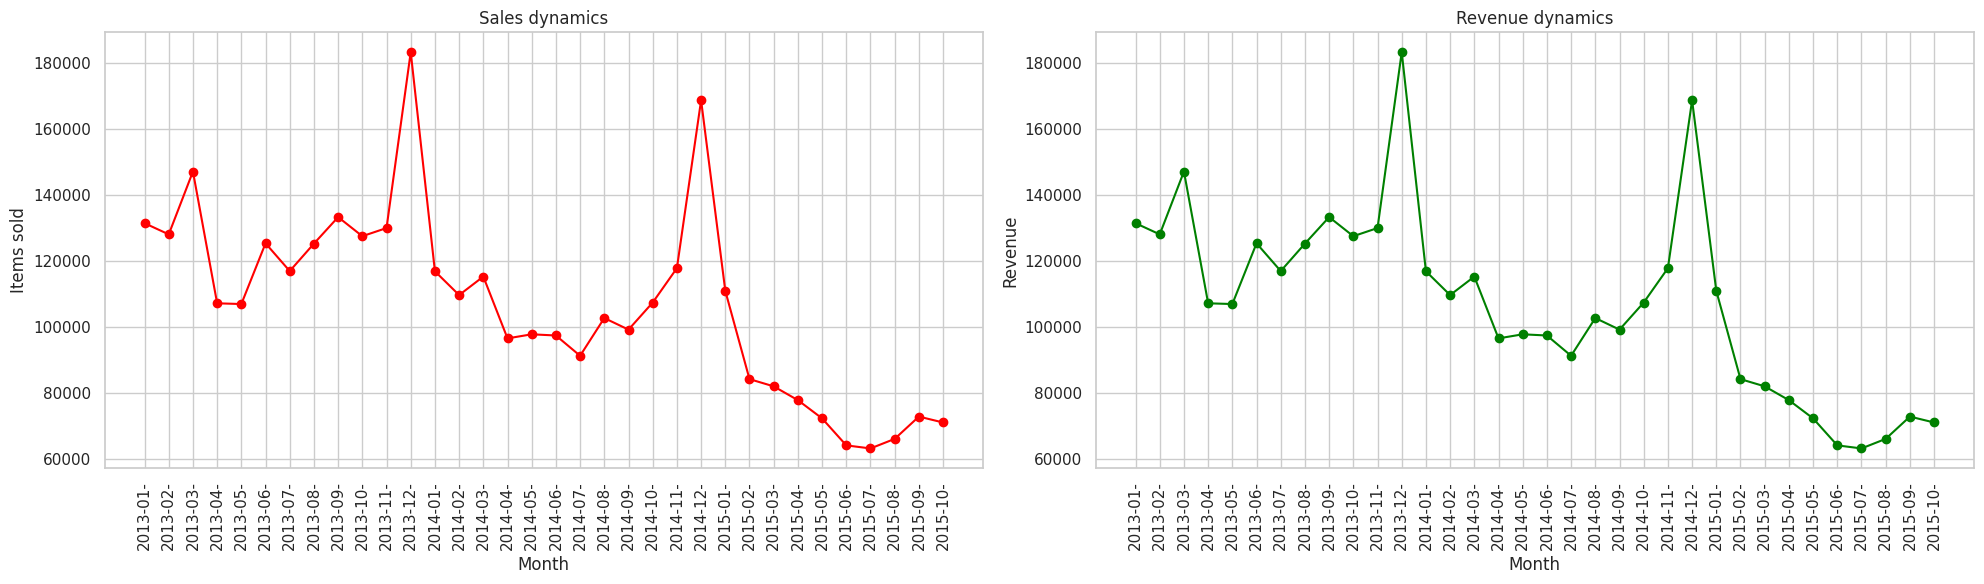

In [ ]:
# Compute monthly totals for items sold and revenue
monthly_total_sales = monthly_sales['item_cnt_day'].sum()
monthly_revenue = monthly_sales['revenue'].sum()

# Define subplots
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# Sales plot
axes[0].plot(monthly_total_sales.index, monthly_total_sales.values, marker='o', color='red')
axes[0].set_title('Sales dynamics')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Items sold')
axes[0].grid(True)
axes[0].tick_params(axis='x', rotation=90)

# Revenue plot
axes[1].plot(monthly_total_sales.index, monthly_total_sales.values, marker='o', color='green')
axes[1].set_title('Revenue dynamics')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Revenue')
axes[1].grid(True)
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()

In [ ]:
train["year"].value_counts()

,count
year,
2013,1267560
2014,1055861
2015,612426


A descending trend is visible, but since the amount of data decreases with each subsequent year, we can't state that sales are falling. There is also seasonality: sales peak in December each year.

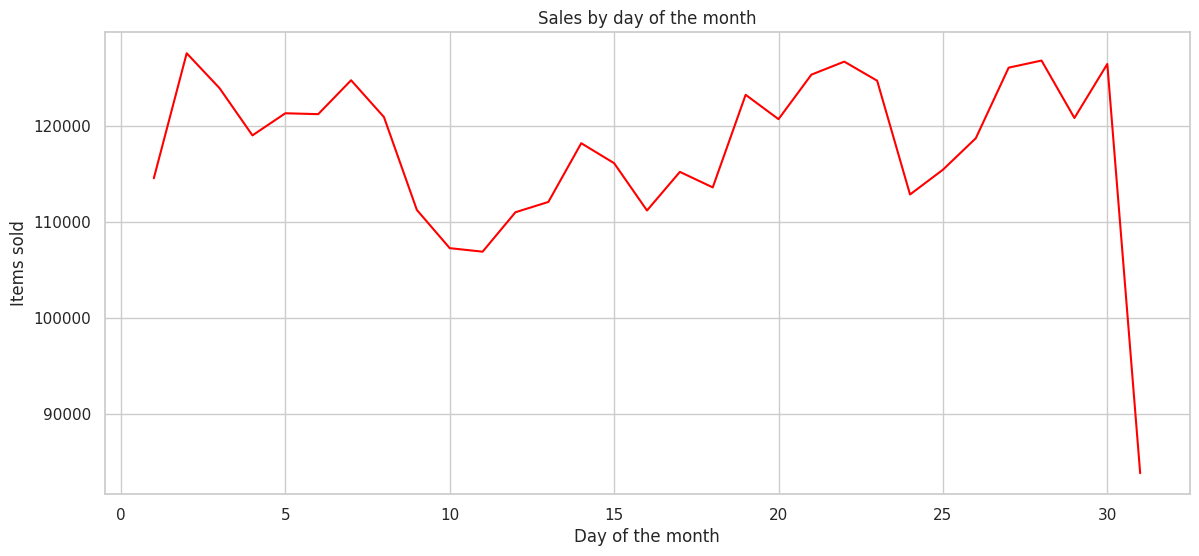

In [ ]:
# Aggregate total items sold by day of the month
day_sales = train.groupby('day')['item_cnt_day'].sum().reset_index()

plt.figure(figsize=(14, 6))
sns.lineplot(data=day_sales, x='day', y='item_cnt_day', color="red")
plt.title('Sales by day of the month')
plt.xlabel('Day of the month')
plt.ylabel('Items sold')
plt.grid(True)
plt.show()

Sales tend to decline around the 10th and 24th of each month. (Note: not all months have 31 days.) People typically receive their salaries at the beginning or middle of the month.
- By the 10th, the first wave of spending subsides. Consumers begin to economize, especially if their salary was used to cover essential expenses such as rent, loans, or utilities.
- Around the 24th, the second wave of spending comes to an end. Funds are running low, and people enter a waiting mode for their next paycheck. As a result, sales drop.

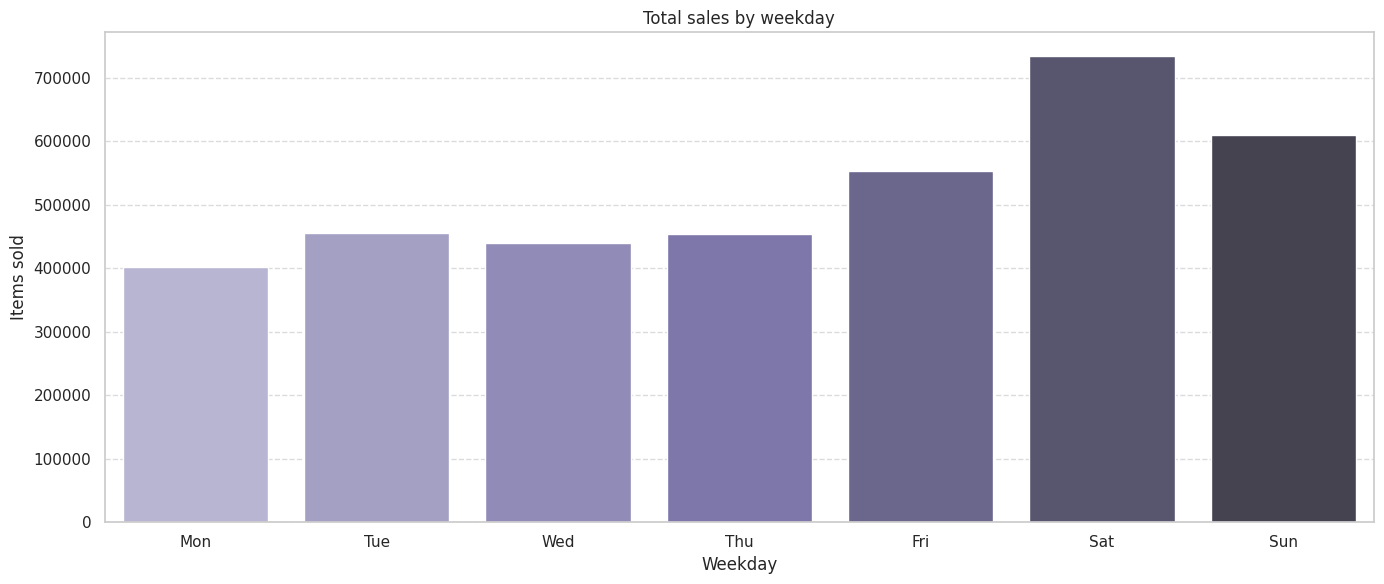

In [ ]:
# Add the weekday feature (0=Mon, 6=Sun)
train['weekday'] = pd.to_datetime(train[['year', 'month', 'day']]).dt.dayofweek

# Aggregate data by weekday and sort
weekday_sales = train.groupby('weekday')['item_cnt_day'].sum().reset_index()

# Weekday labels
weekday_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
weekday_sales['weekday_name'] = weekday_sales['weekday'].map(dict(zip(range(7), weekday_labels)))

# Plotting
plt.figure(figsize=(14, 6))
sns.barplot(
    data=weekday_sales,
    x='weekday_name',
    y='item_cnt_day',
    hue='weekday_name',
    palette='Purples_d',
    legend=False
)

plt.title('Total sales by weekday')
plt.xlabel('Weekday')
plt.ylabel('Items sold')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Sales reach their highest levels near the weekend.

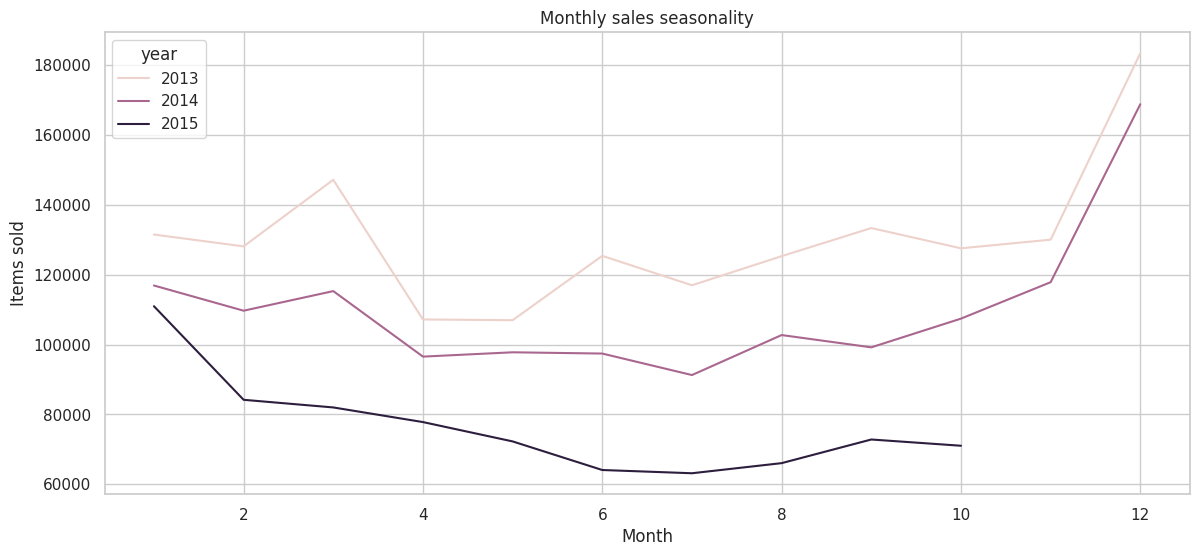

In [ ]:
# Visualize monthly sales seasonality across years
plt.figure(figsize=(14, 6))

# Aggregate total items sold by year and month
seasonal = train.groupby(["year", "month"])['item_cnt_day'].sum().reset_index()

# Plot monthly sales trends with year-wise comparison
sns.lineplot(data=seasonal, x='month', y='item_cnt_day', hue='year')
plt.title('Monthly sales seasonality')
plt.xlabel('Month')
plt.ylabel('Items sold')
plt.show()

Sales tend to peak near the end of the year, probably because people enjoy gifting video games during the winter holidays

### Prices

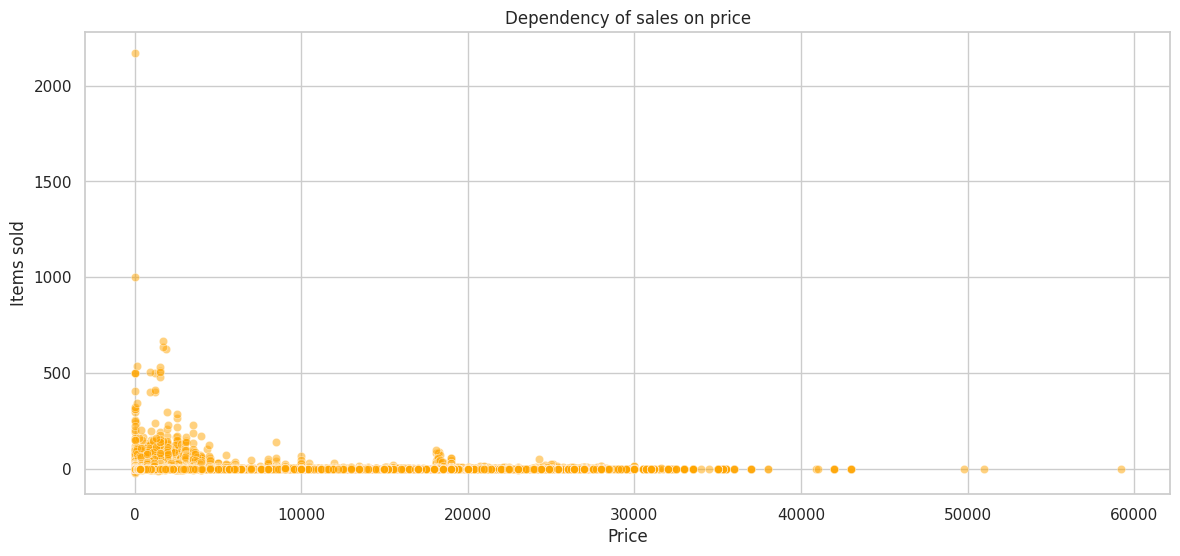

In [ ]:
# Scatter plot showing the relationship between item price and quantity sold
plt.figure(figsize=(14, 6))
sns.scatterplot(data=train, x='item_price', y='item_cnt_day', alpha=0.5, color='orange')
plt.title('Dependency of sales on price')
plt.xlabel('Price')
plt.ylabel('Items sold')
plt.grid(True)
plt.show()

The observed decline in sales with increasing price confirms consumers' sensitivity to product cost.

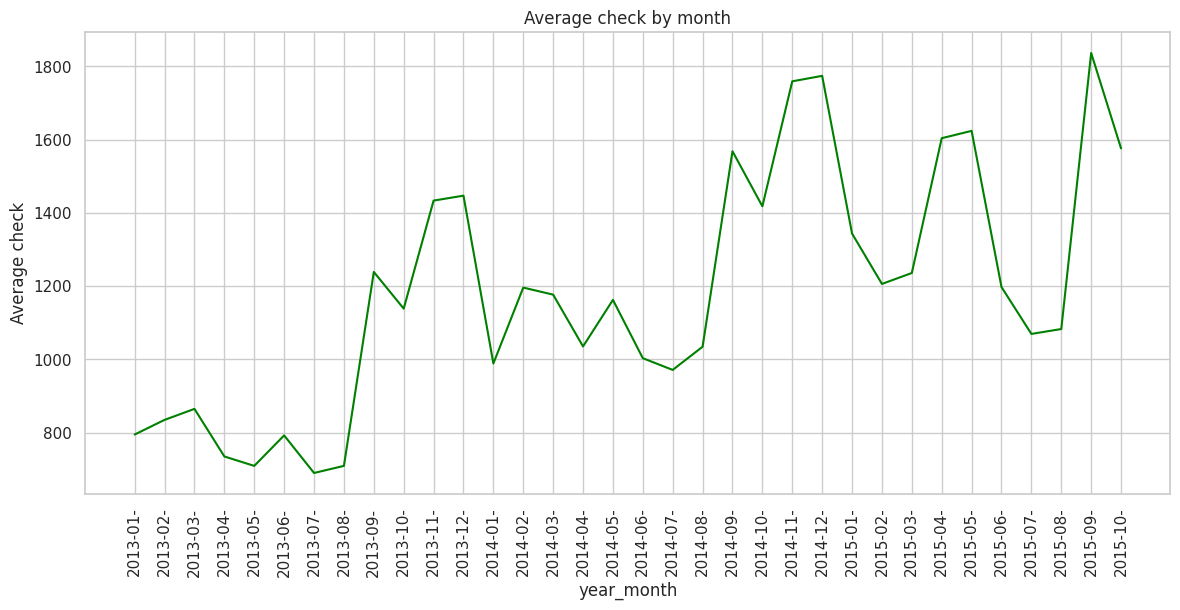

In [ ]:
# Average check
monthly_price = monthly_sales['revenue'].mean().reset_index()

plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_price, x='year_month', y='revenue', color="green")
plt.title('Average check by month')
plt.xlabel('year_month')
plt.ylabel('Average check')
plt.grid(True)
plt.tick_params(axis='x', rotation=90)
plt.show()

Over the three-year period, the average check increased from 800 to 1600 units. Adjusted for inflation, this represents a real growth of approximately 70%. The peak was reached in September 2015.

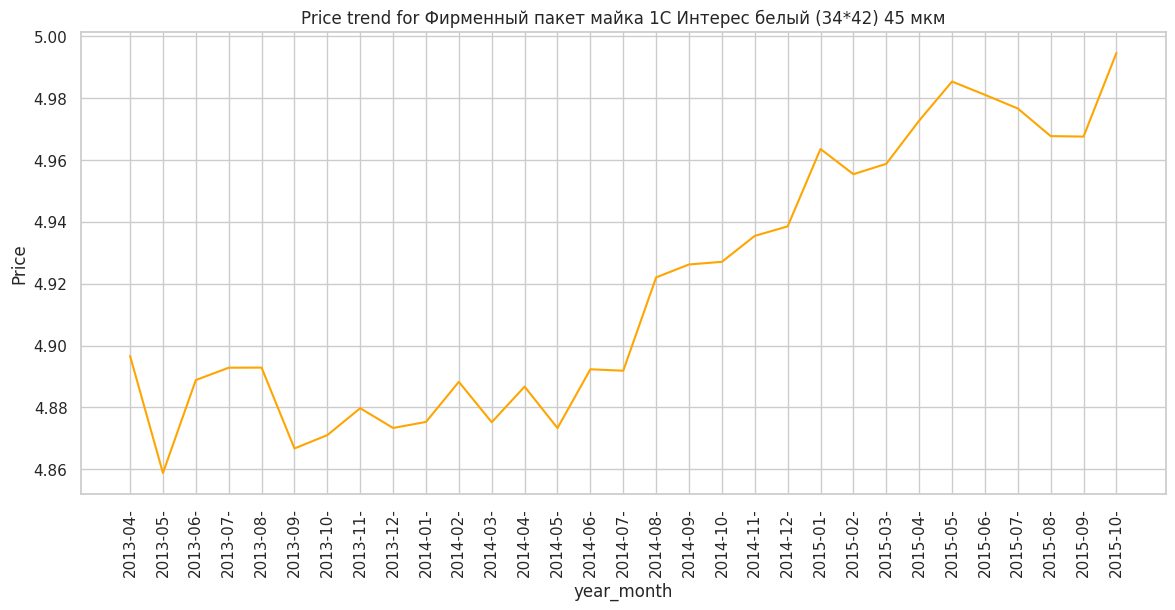

In [ ]:
# Price trend of the most popular item
item_name_example = train['item_name'].value_counts().index[0]  # the most popular item
item_price_trend = train[train['item_name'] == item_name_example].groupby("year_month")['item_price'].mean().reset_index()

plt.figure(figsize=(14, 6))
sns.lineplot(data=item_price_trend, x='year_month', y='item_price', color="orange")
plt.title(f'Price trend for {item_name_example}')
plt.xlabel('year_month')
plt.ylabel('Price')
plt.grid(True)
plt.tick_params(axis='x', rotation=90)
plt.show()

The price of a popular item increased from 4.89 to 4.99 units over three years — a modest rise of 0.1 units (2%). The most frequently purchased item was a plastic bag.

In [ ]:
# Compute average price per item
avg_prices = train.groupby('item_name')['item_price'].mean()

# Define quantile-based price thresholds
low, high = avg_prices.quantile([0.33, 0.66])

# Select top-N items per price category with sufficient monthly history
def select_items(price_range, label, top_n=5, min_months=6):
    items = avg_prices[price_range].sort_values(ascending=False).index
    counts = train[train['item_name'].isin(items)].groupby('item_name')['year_month'].nunique()
    selected = counts[counts >= min_months].sort_values(ascending=False).head(top_n).index.tolist()
    return selected, {item: label for item in selected}

# Categorize items by price level
cheap, cheap_map = select_items(avg_prices <= low, 'Low')
mid, mid_map = select_items((avg_prices > low) & (avg_prices < high), 'Mid')
expensive, expensive_map = select_items(avg_prices >= high, 'High')

# Combine selected items and assign category labels
selected_items = cheap + mid + expensive
category_map = {**cheap_map, **mid_map, **expensive_map}

# Filter dataset and assign price category
filtered = train[train['item_name'].isin(selected_items)].copy()
filtered['category'] = filtered['item_name'].map(category_map)

# Group by item and month, compute smoothed price trends
price_trends = (
    filtered.groupby(['item_name', 'year_month', 'category'])['item_price']
    .mean()
    .reset_index()
)
price_trends['smoothed_price'] = (
    price_trends.groupby('item_name')['item_price']
    .transform(lambda x: x.rolling(window=2, min_periods=1).mean())
)

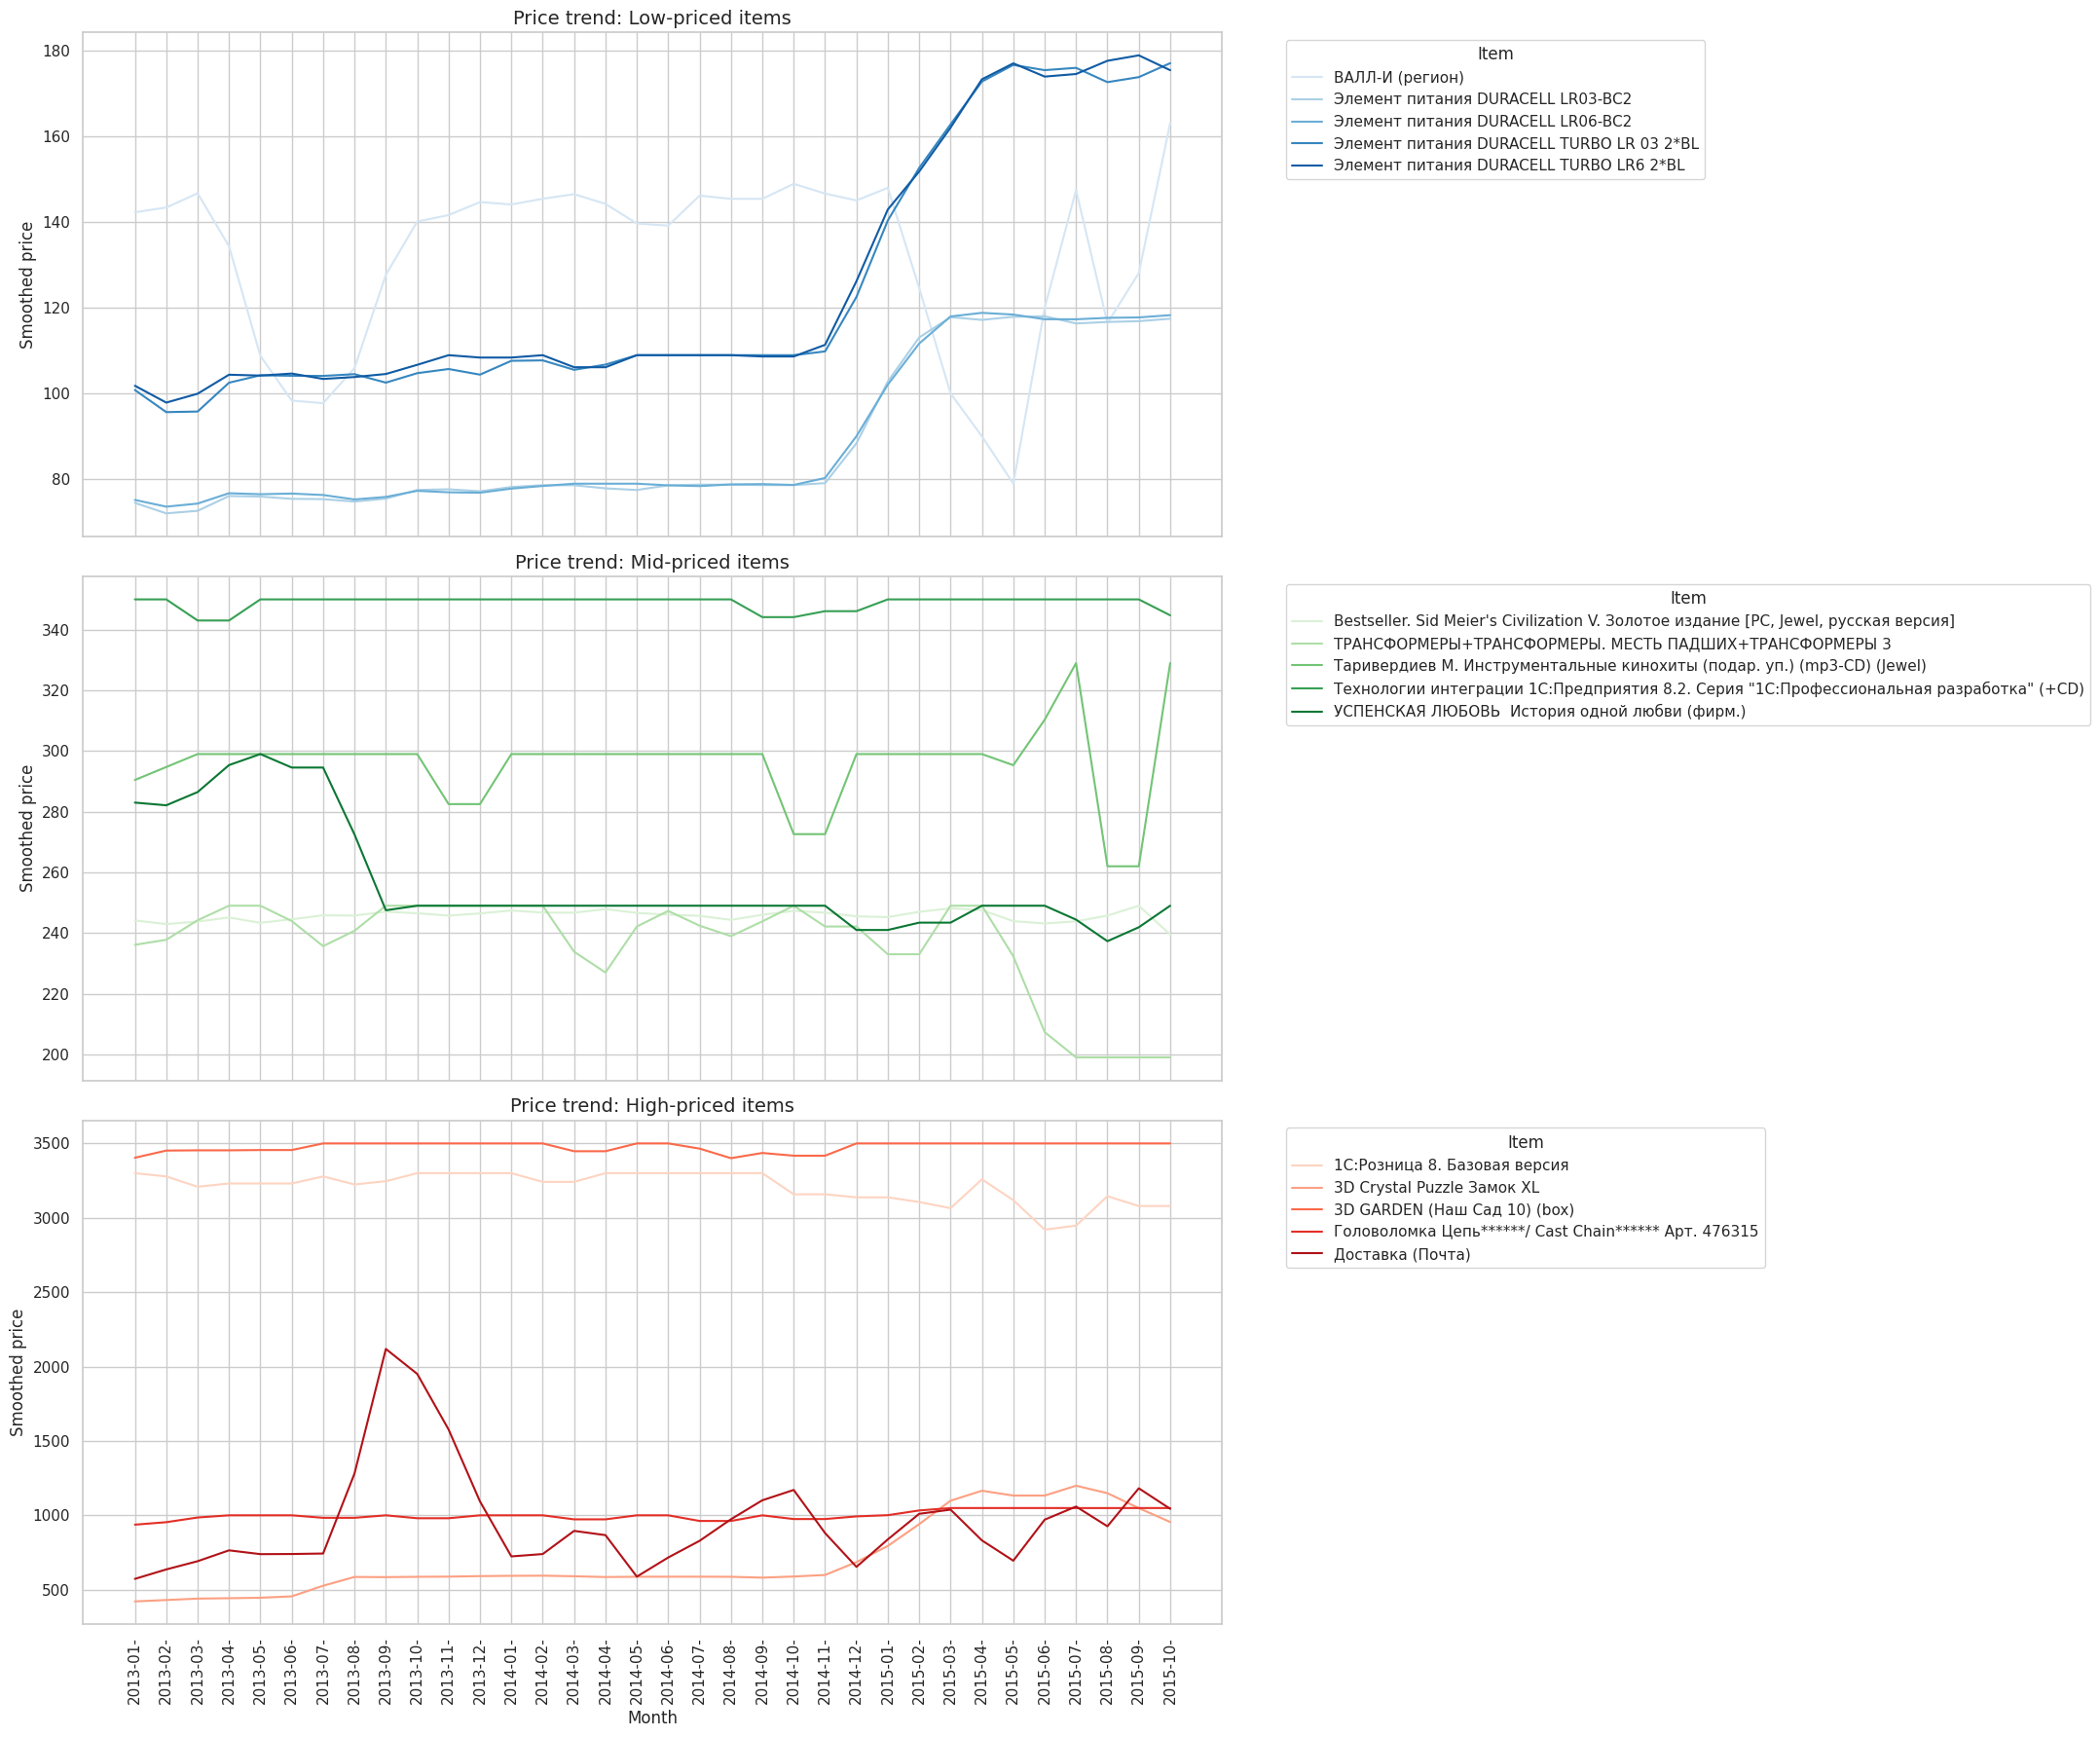

In [ ]:
# Visualize smoothed price trends by category
fig, axes = plt.subplots(3, 1, figsize=(22, 18), sharex=True)
categories = ['Low', 'Mid', 'High']
palettes = ['Blues', 'Greens', 'Reds']

for i, (cat, palette) in enumerate(zip(categories, palettes)):
    subset = price_trends[price_trends['category'] == cat]
    sns.lineplot(
        data=subset,
        x='year_month',
        y='smoothed_price',
        hue='item_name',
        ax=axes[i],
        palette=palette
    )
    axes[i].set_title(f'Price trend: {cat}-priced items', fontsize=14)
    axes[i].set_ylabel('Smoothed price')
    axes[i].grid(True)
    axes[i].legend(title='Item', bbox_to_anchor=(1.05, 1), loc='upper left')

axes[-1].set_xlabel('Month')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()



- Among low-priced items, a sharp price increase is observed in the second half of the period (notably for DURACELL batteries), which may indicate a shift in demand.

- Mid-priced items show overall price stability with occasional spikes (seen in games and books), possibly reflecting seasonal promotions or supply fluctuations.

- High-priced items exhibit significant volatility (especially in delivery services and rare editions).

### Items and categories

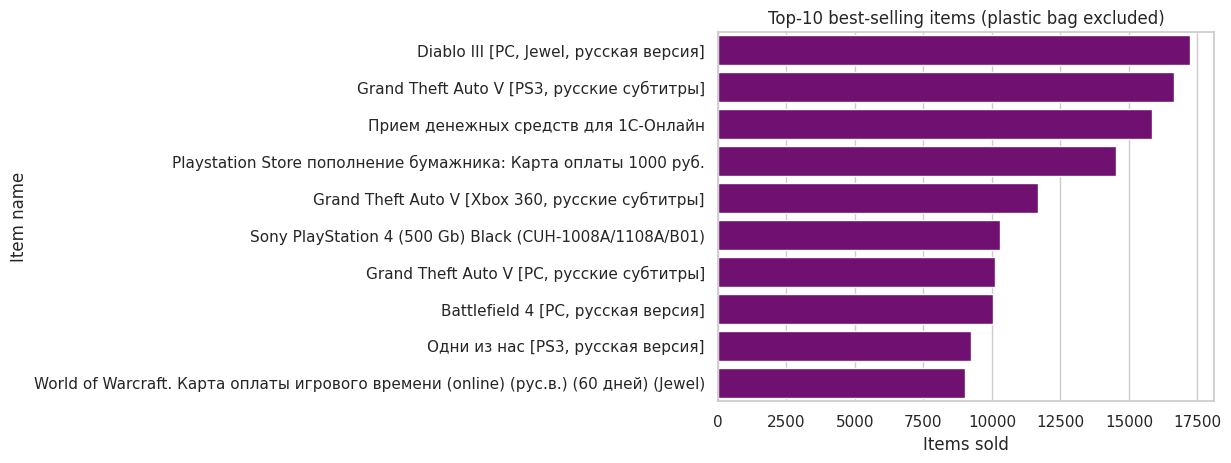

In [ ]:
# Top-10 best-selling items (excluding plastic bags)

# Aggregate and select top 10 (excluding the absolute top item)
top_items = (
    train.groupby('item_name')['item_cnt_day']
    .sum()
    .sort_values(ascending=False)[1:11]
)

# Plot item sales
sns.barplot(y=top_items.index, x=top_items.values, color="purple")

plt.title('Top-10 best-selling items (plastic bag excluded)')
plt.xlabel('Items sold')
plt.ylabel('Item name')
plt.show()

The store’s most popular items are video games and gaming accessories, particularly for PlayStation and PC platforms, indicating a clear specialization in digital entertainment and gaming.

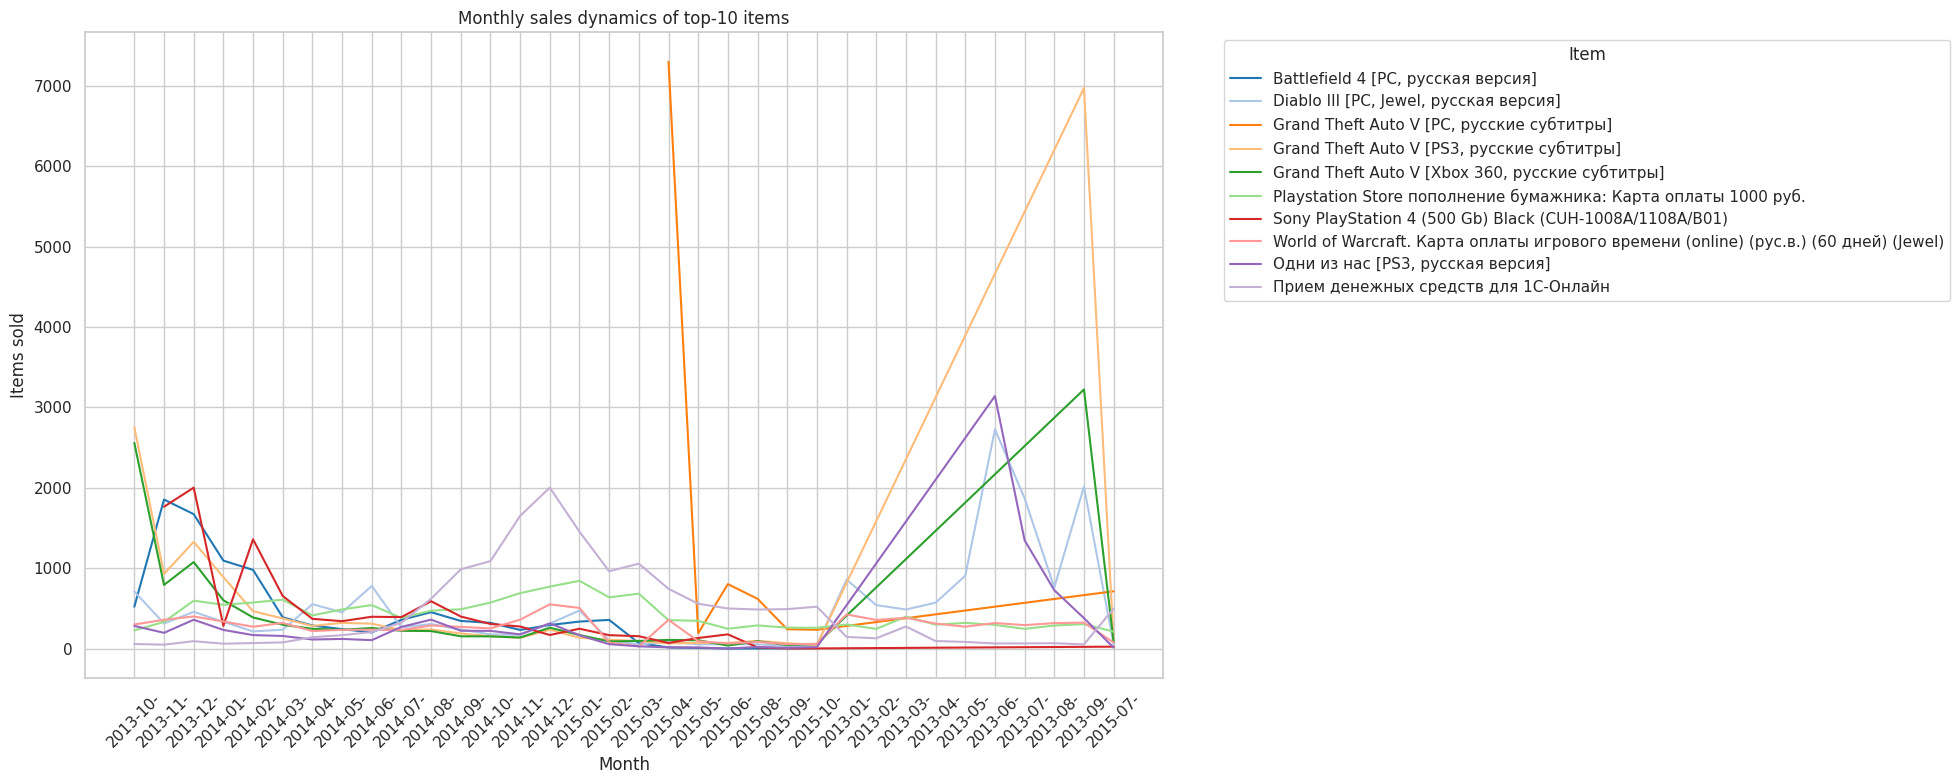

In [ ]:
# Select top-10 items
top_item_names = top_items.index.tolist()

# Filter data for these items
filtered = train[train['item_name'].isin(top_item_names)]

# Group by item and month
item_monthly = (
    filtered.groupby(['item_name', 'year_month'])['item_cnt_day']
    .sum()
    .reset_index()
)

# Plot monthly sales dynamics for top-10 items
plt.figure(figsize=(20, 8))
sns.lineplot(data=item_monthly, x='year_month', y='item_cnt_day', hue='item_name', palette='tab20')

plt.title('Monthly sales dynamics of top-10 items')
plt.xlabel('Month')
plt.ylabel('Items sold')
plt.xticks(rotation=45)
plt.legend(title='Item', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.grid(True)

Most top-selling items show a sharp sales spike early in the period, followed by a rapid decline, likely driven by short-term promotions or seasonal demand.

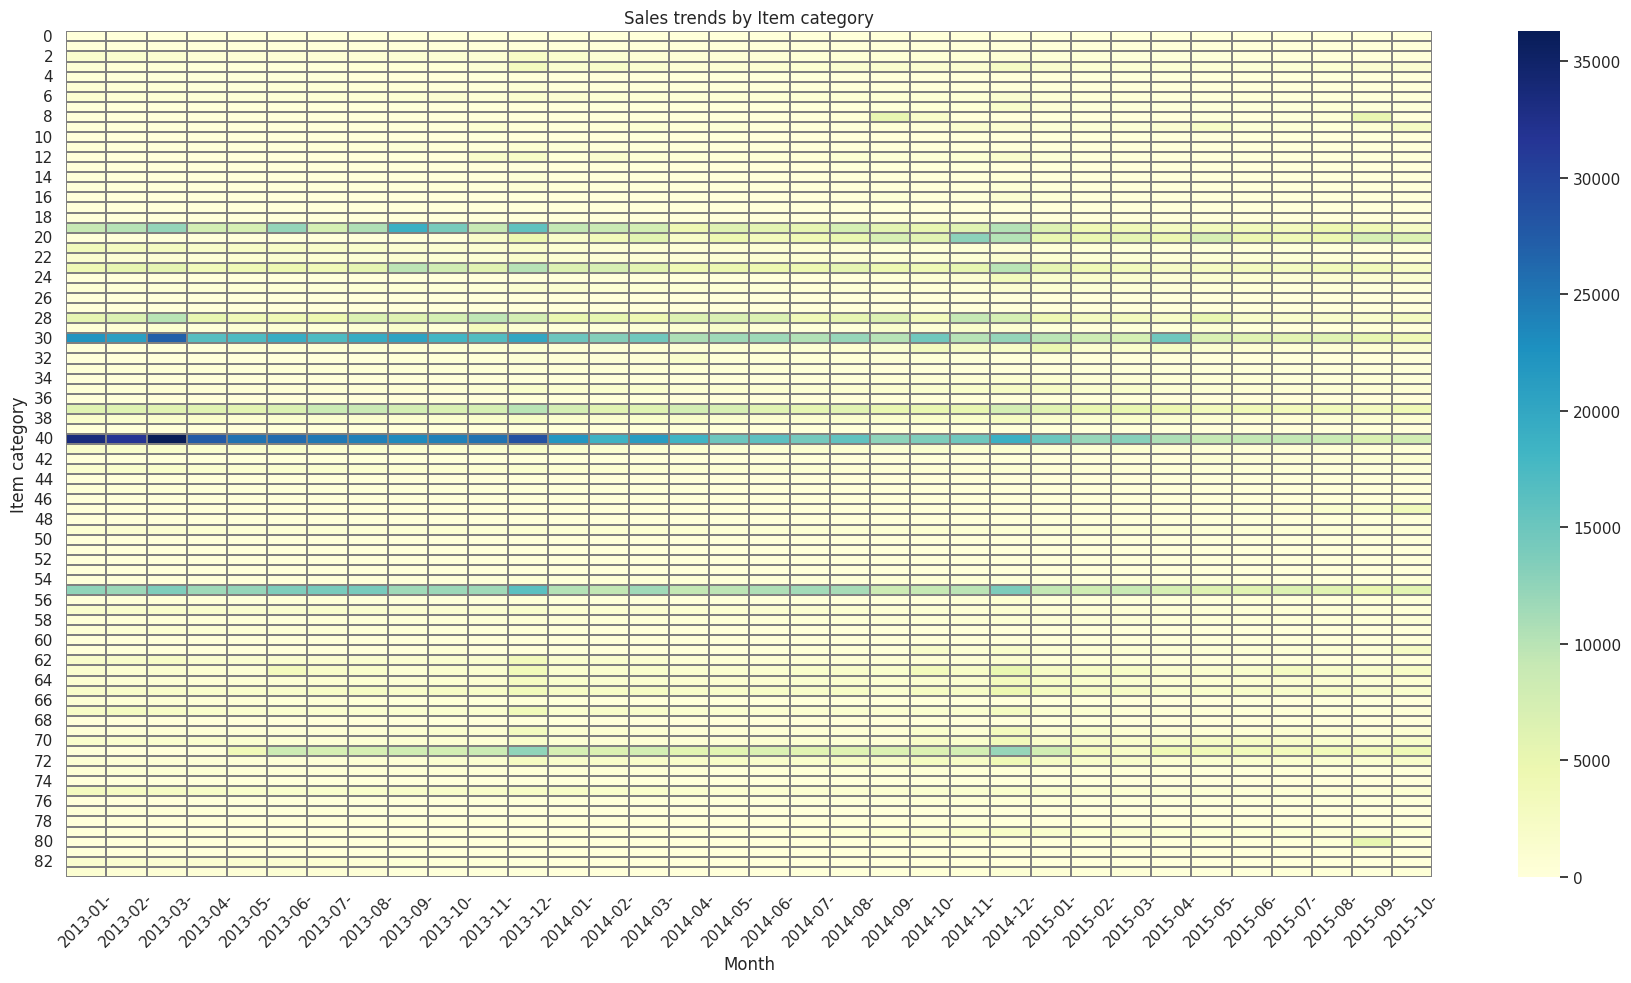

In [ ]:
# Aggregate monthly sales by item category
category_monthly = (
    train.groupby(['year_month', 'item_category_id'])['item_cnt_day']
    .sum()
    .reset_index()
)

# Pivot to matrix: rows = categories, columns = months
heatmap_data = category_monthly.pivot(index='item_category_id', columns='year_month', values='item_cnt_day')

# Fill missing values with zeros
heatmap_data = heatmap_data.fillna(0)

# Plot heatmap of category-level sales trends
plt.figure(figsize=(18, 10))
sns.heatmap(heatmap_data, cmap='YlGnBu', linewidths=0.3, linecolor='gray')
plt.title('Sales trends by Item category')
plt.xlabel('Month')
plt.ylabel('Item category')
plt.xticks(rotation=45)
plt.tight_layout()

Most item categories have low sales. All of them demonstrate descending trend. Our shops specialise on 40 category of goods.

In [ ]:
category_item_counts = (
    train.groupby('item_category_id')['item_id']
    .nunique()
    .sort_values(ascending=False)
)

print("Top categories by number of unique items\n", category_item_counts.head(7))
print("\nBottom categories by number of unique items\n", category_item_counts.tail(7))

Top categories by number of unique items
 item_category_id
40    4964
55    2327
37    1777
31    1100
58     769
30     751
72     638
Name: item_id, dtype: int64

Bottom categories by number of unique items
 item_category_id
53    3
26    3
1     2
50    2
10    1
51    1
79    1
Name: item_id, dtype: int64


In [ ]:
# Aggregate total sales by item category
category_sales = train.groupby('item_category_id')['item_cnt_day'].sum()
category_sales = category_sales.sort_values(ascending=False)

# Select top 7 and bottom 7 categories by total sales
top_7 = category_sales.head(7).index.tolist()
bottom_7 = category_sales.tail(7).index.tolist()
selected_categories = top_7 + bottom_7

# Filter dataset to include only selected categories
filtered_df = train[train['item_category_id'].isin(selected_categories)]

# Aggregate monthly sales for selected categories
monthly_sales = (
    filtered_df
    .groupby(['year_month', 'item_category_id'])['item_cnt_day']
    .sum()
    .reset_index()
)

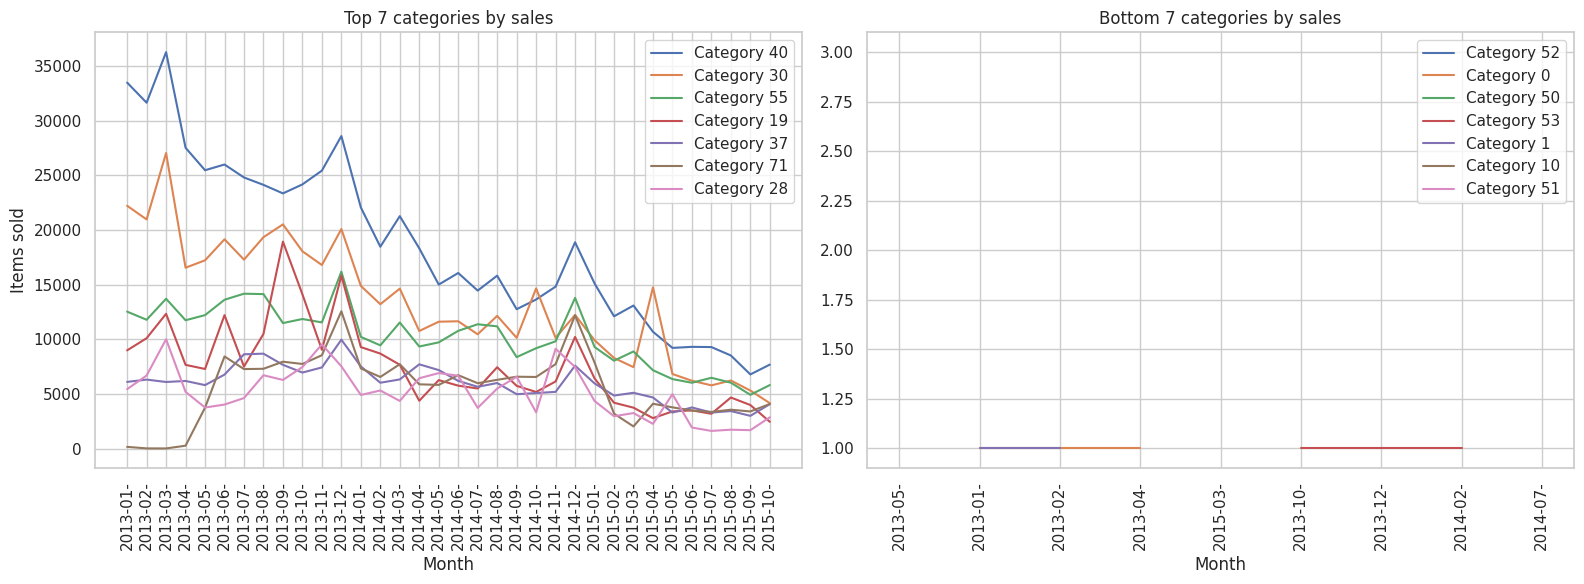

In [ ]:
# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)

# Plot sales trends for top 7 categories
for cat_id in top_7:
    data = monthly_sales[monthly_sales['item_category_id'] == cat_id]
    axes[0].plot(data['year_month'], data['item_cnt_day'], label=f'Category {cat_id}')
axes[0].set_title('Top 7 categories by sales')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Items sold')
axes[0].legend()
axes[0].grid(True)
axes[0].tick_params(axis="x", rotation=90)

# Plot sales trends for bottom 7 categories
for cat_id in bottom_7:
    data = monthly_sales[monthly_sales['item_category_id'] == cat_id].sort_values('year_month')
    axes[1].plot(data['year_month'], data['item_cnt_day'], label=f'Category {cat_id}')
axes[1].set_title('Bottom 7 categories by sales')
axes[1].set_xlabel('Month')
axes[1].legend()
axes[1].grid(True)
axes[1].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

Sales in the top 7 categories exhibit clear seasonality and an overall decline since early 2013, with the first three categories showing the most pronounced drop. In contrast, the bottom 7 categories show virtually no sales, which may indicate outdated or irrelevant product groups.

While the top-selling categories align with those containing the highest number of unique items, the categories with the fewest unique items do not correspond to the lowest sales volumes.

### Shops and cities

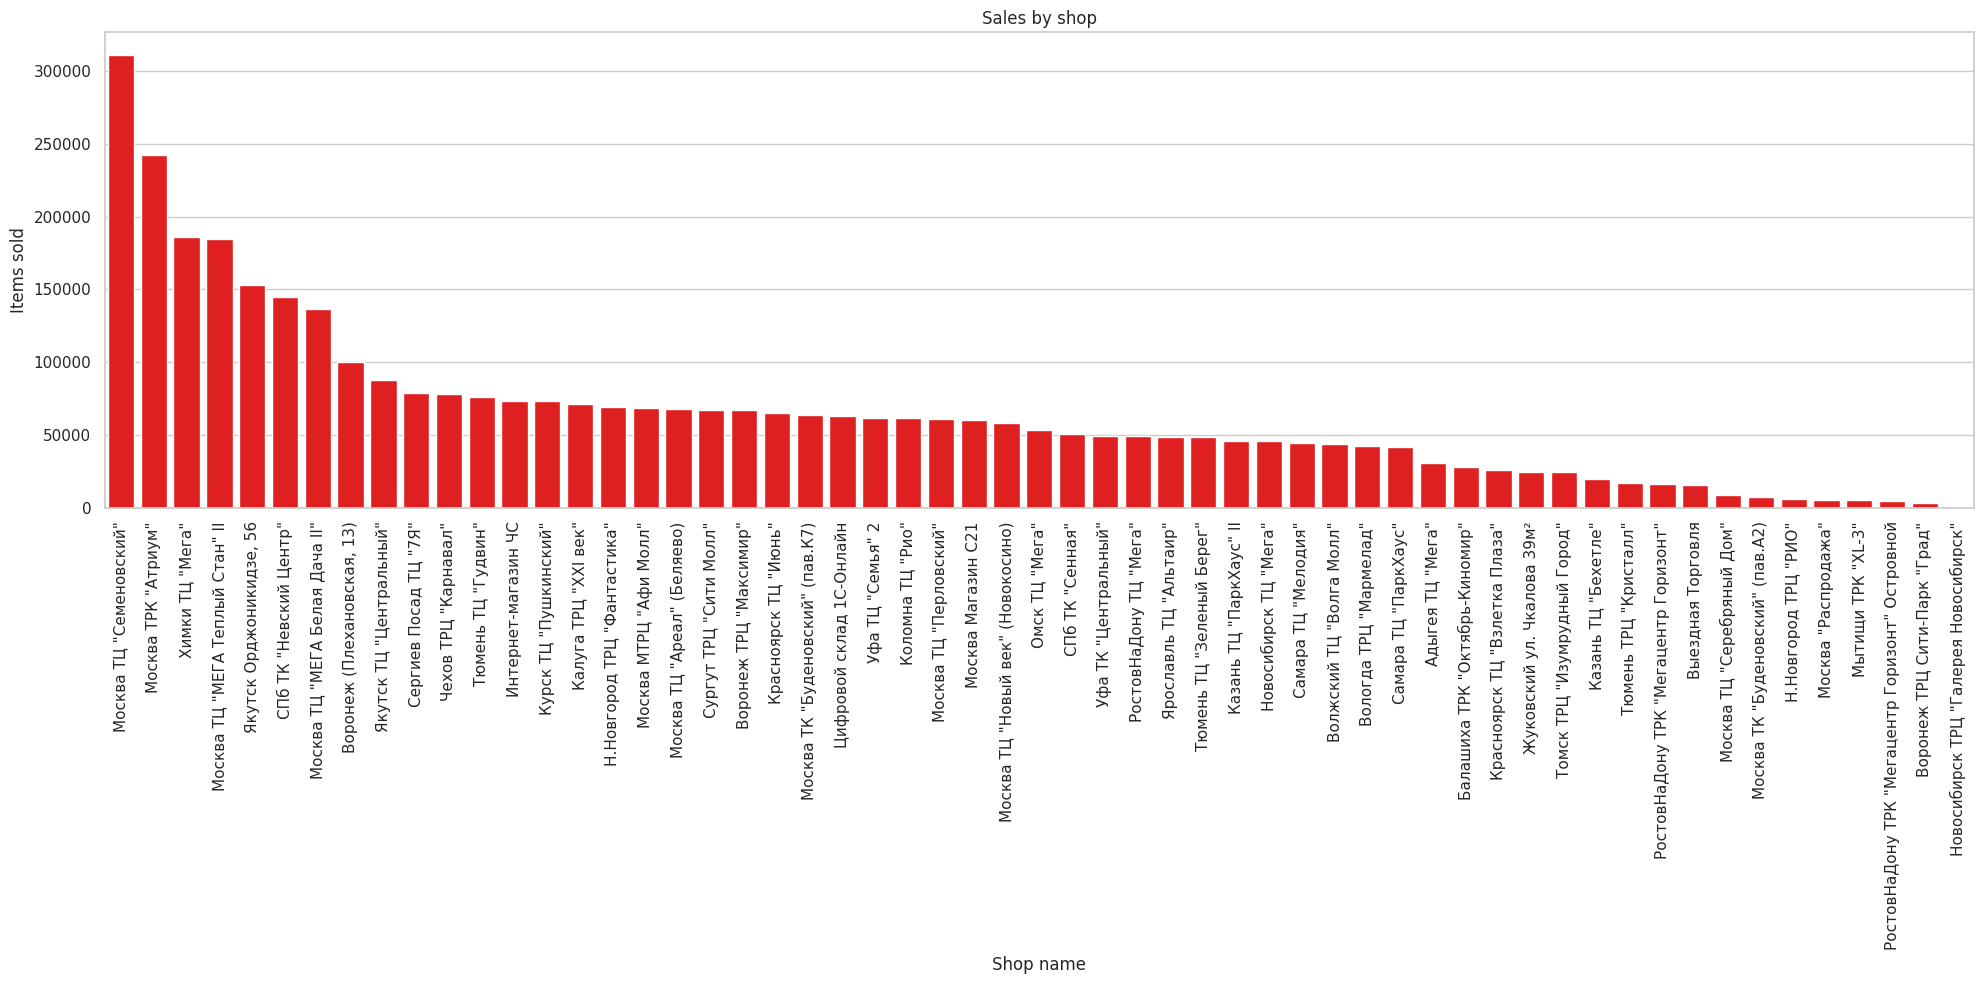

In [ ]:
# Sales by shop
shop_sales = train.groupby('shop_name')['item_cnt_day'].sum().reset_index()
shop_sales = shop_sales.sort_values(by='item_cnt_day', ascending=False)

plt.figure(figsize=(20, 10))

sns.barplot(
    data=shop_sales,
    x="shop_name",
    y='item_cnt_day',
    order=shop_sales['shop_name'].tolist(),
    color="red"
)

plt.title('Sales by shop')
plt.xlabel('Shop name')
plt.ylabel('Items sold')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Shops in Moscow, Khimki, and Yakutsk are leading the top. Shops in Mytishchi, Rostov, Voronezh, and Novosibirsk are outsiders.

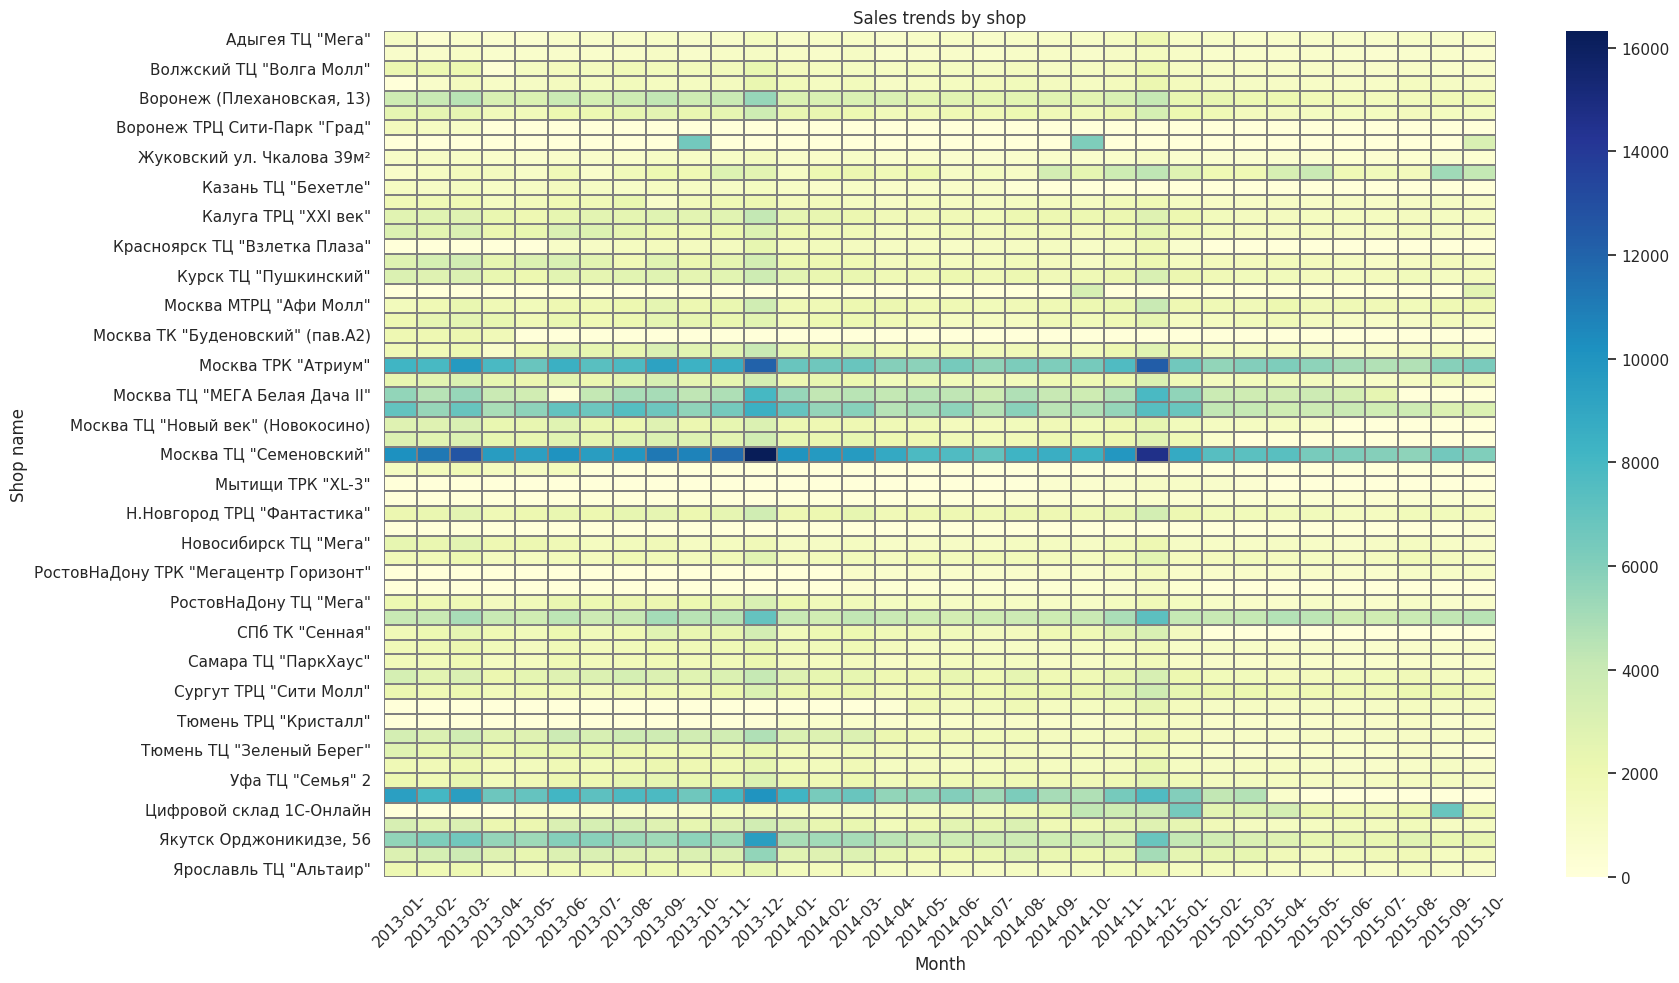

In [ ]:
# Aggregate monthly sales by shop
shop_monthly = (
    train.groupby(['year_month', 'shop_name'])['item_cnt_day']
    .sum()
    .reset_index()
)

# Pivot to matrix: rows = shops, columns = months
heatmap_data = shop_monthly.pivot(index='shop_name', columns='year_month', values='item_cnt_day')

# Fill missing values with zeros
heatmap_data = heatmap_data.fillna(0)

# Plot heatmap of shop-level sales trends
plt.figure(figsize=(18, 10))
sns.heatmap(heatmap_data, cmap='YlGnBu', linewidths=0.3, linecolor='gray')
plt.title('Sales trends by shop')
plt.xlabel('Month')
plt.ylabel('Shop name')
plt.xticks(rotation=45)
plt.tight_layout()

A few standout shops, like Москва ТЦ "МЕГА Белая Дача" and Химки ТЦ "МЕГА", consistently show high sales volumes across time, dominating the heatmap with darker shades. In contrast, shops such as Мытищи ТЦ "Июнь" and Ростов ТЦ "Золотой Вавилон" remain in lighter tones, indicating persistently lower sales and limited seasonal impact.

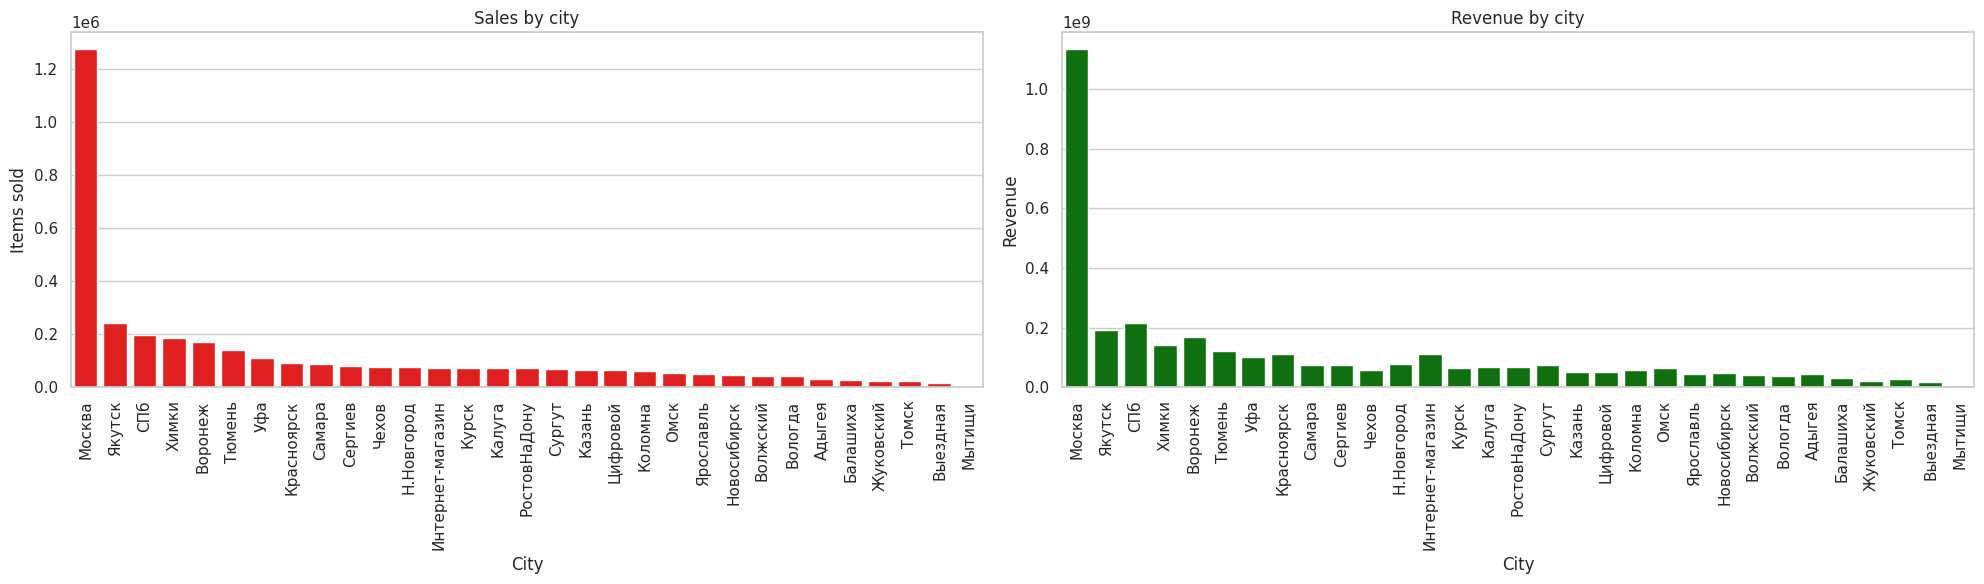

In [ ]:
# Extract city name from shop_name
train['city'] = train['shop_name'].str.split().str[0]

# Group total sales and revenue by city
city_sales = train.groupby('city')['item_cnt_day'].sum().reset_index()
city_revenue = train.groupby('city')['revenue'].sum().reset_index()

# Sort cities by total sales
city_sales = city_sales.sort_values(by='item_cnt_day', ascending=False)

# Align revenue data to match sales order
city_revenue = city_revenue.set_index('city').loc[city_sales['city']].reset_index()

# Create side-by-side bar charts for sales and revenue
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# Sales by city
sns.barplot(data=city_sales, x='city', y='item_cnt_day', ax=axes[0], color="red")
axes[0].set_title('Sales by сity')
axes[0].set_xlabel('City')
axes[0].set_ylabel('Items sold')
axes[0].tick_params(axis='x', rotation=90)

# Revenue by city
sns.barplot(data=city_revenue, x='city', y='revenue', ax=axes[1], color="green")
axes[1].set_title('Revenue by сity')
axes[1].set_xlabel('City')
axes[1].set_ylabel('Revenue')
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

Sales in Moscow are the highest, as is the number of stores in the city. The least profitable city is Mytishchi.

In [ ]:
# Count unique shops in cities
shop_counts = train[['shop_id', 'city']].drop_duplicates()
city_shop_counts = (
    shop_counts
    .groupby('city')['shop_id']
    .nunique()
    .reset_index()
    .sort_values(by='shop_id', ascending=False)
)
city_shop_counts = city_shop_counts.rename(columns={"shop_id": "shop_count"})
city_shop_counts

,city,shop_count
13,Москва,13
4,Воронеж,3
18,РостовНаДону,3
24,Тюмень,3
16,Новосибирск,2
11,Красноярск,2
8,Казань,2
19,СПб,2
25,Уфа,2
29,Якутск,2


In smaller cities, the company typically operates only one shop, which may indicate a business expansion strategy originating from Moscow and gradually extending into peripheral regions.

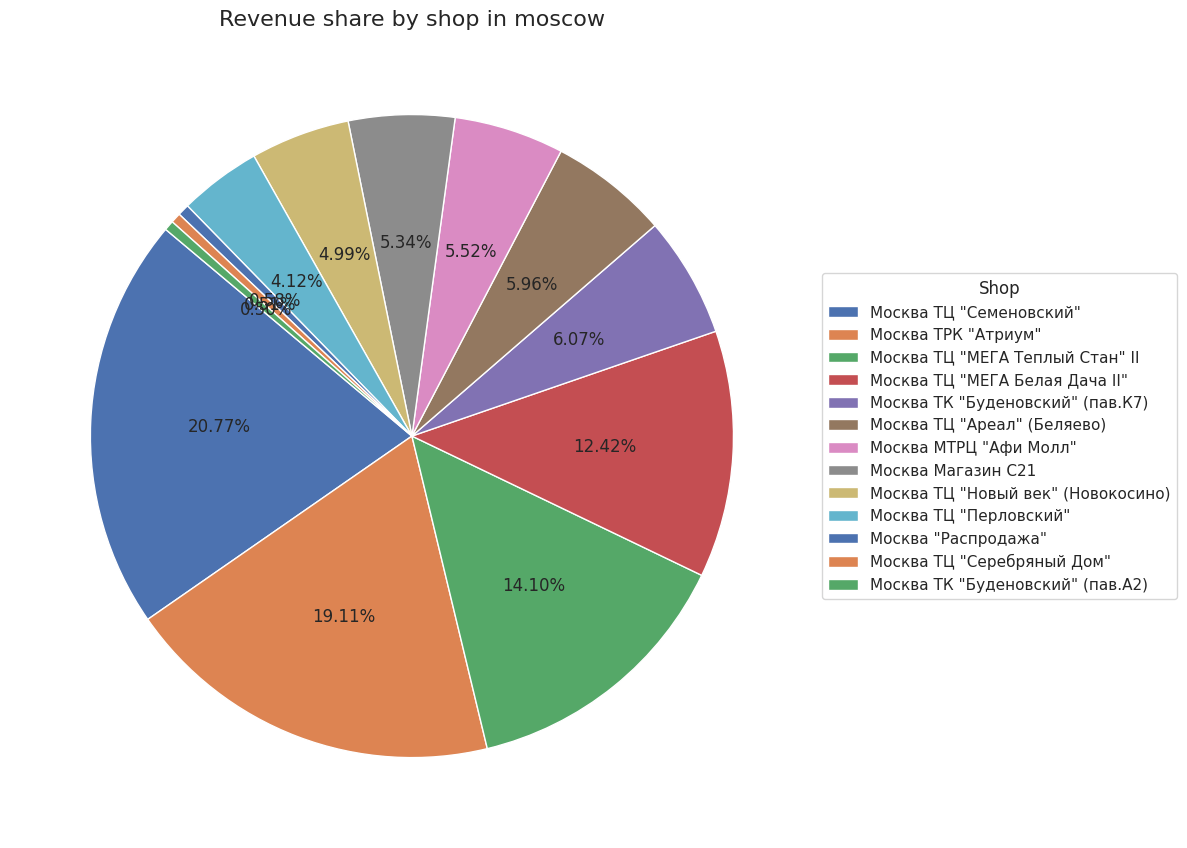

In [ ]:
# Map shop_id to shop_name from train dataset
shop_id_to_name = (
    train[['shop_id', 'shop_name']]
    .drop_duplicates()
    .set_index('shop_id')['shop_name']
    .to_dict()
)

# Filter shops located in Moscow
moscow_shop_ids = shop_counts[shop_counts['city'] == 'Москва']['shop_id'].tolist()

# Calculate total revenue per shop in Moscow
moscow_revenue = (
    train[train['shop_id'].isin(moscow_shop_ids)]
    .groupby('shop_id')['revenue']
    .sum()
    .sort_values(ascending=False)
)

# Retrieve shop names for labeling
labels = [shop_id_to_name.get(sid, f'Shop {sid}') for sid in moscow_revenue.index]

# Pie chart visualization with legend
fig, ax = plt.subplots(figsize=(12, 12))
wedges, texts, autotexts = ax.pie(
    moscow_revenue,
    labels=None,
    autopct='%1.2f%%',
    startangle=140,
    wedgeprops={'edgecolor': 'white'}
)

# Add legend with shop names
ax.legend(
    wedges,
    labels,
    title='Shop',
    loc='center left',
    bbox_to_anchor=(1, 0.5)
)

ax.set_title('Revenue share by shop in moscow', fontsize=16)
plt.tight_layout()
plt.show()


In Moscow, nearly half of the total revenue is generated by just four shops. Six shops contribute around 5% each, while three underperformers account for less than 1% of the overall revenue.

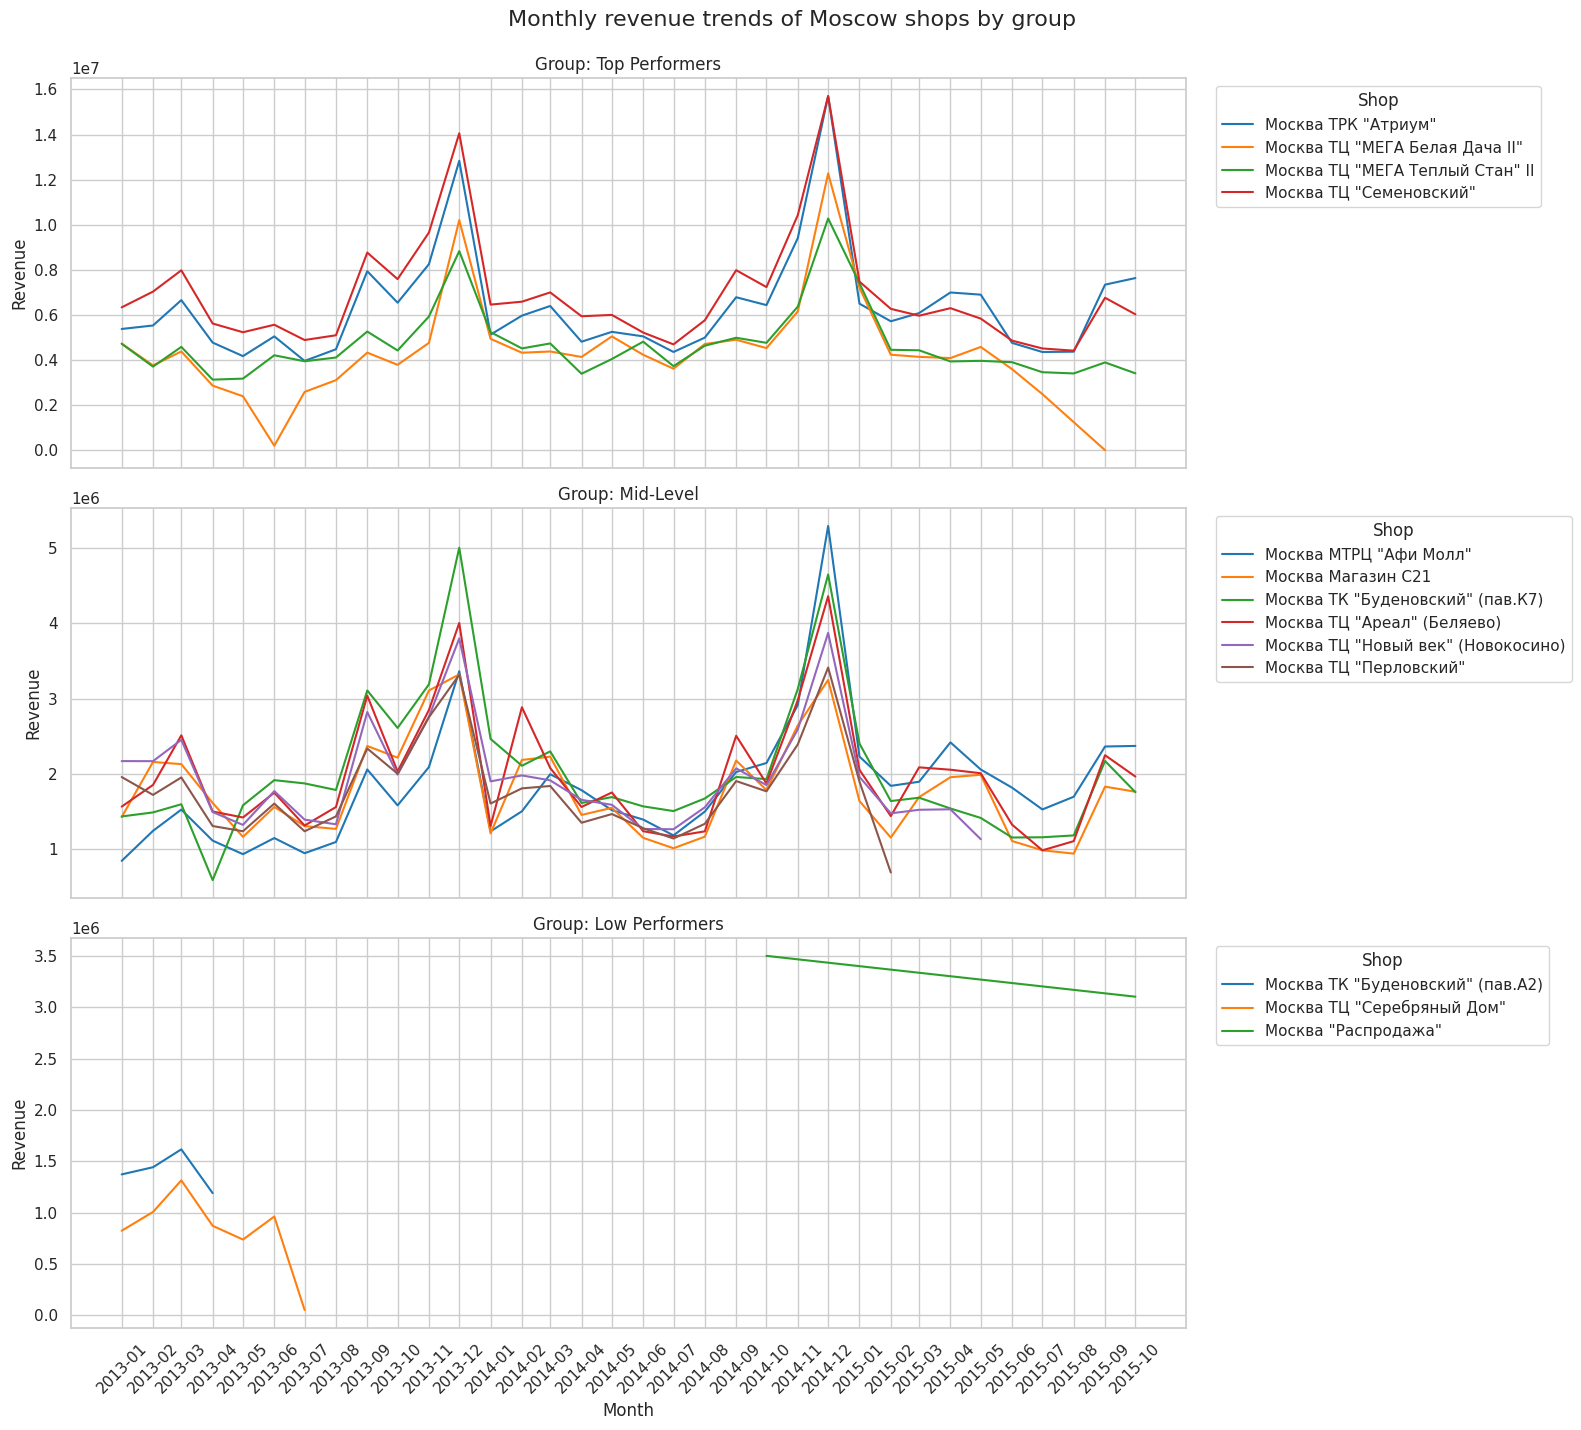

In [ ]:
# Группировка магазинов
top_4_ids = moscow_revenue.head(4).index.tolist()
middle_6_ids = moscow_revenue.iloc[4:-3].sort_values(ascending=False).head(6).index.tolist()
bottom_3_ids = moscow_revenue.tail(3).index.tolist()

def assign_group(shop_id):
    if shop_id in top_4_ids:
        return 'Top Performers'
    elif shop_id in middle_6_ids:
        return 'Mid-Level'
    elif shop_id in bottom_3_ids:
        return 'Low Performers'
    return None

# Подготовка данных
moscow_sales = train[train['shop_id'].isin(top_4_ids + middle_6_ids + bottom_3_ids)].copy()
moscow_sales['group'] = moscow_sales['shop_id'].apply(assign_group)
moscow_sales['shop_name'] = moscow_sales['shop_id'].map(shop_id_to_name)

# Преобразование даты
moscow_sales['year_month'] = pd.to_datetime(moscow_sales['date']).dt.to_period('M').astype(str)

# Агрегация
sales_trend = (
    moscow_sales.groupby(['year_month', 'shop_name', 'group'])['revenue']
    .sum()
    .reset_index()
)

# Преобразование year_month в datetime
sales_trend['year_month'] = pd.to_datetime(sales_trend['year_month'], format='%Y-%m')
month_order = sorted(sales_trend['year_month'].unique())

# Построение графиков
groups = ['Top Performers', 'Mid-Level', 'Low Performers']
fig, axes = plt.subplots(3, 1, figsize=(16, 14), sharex=True)

for ax, group in zip(axes, groups):
    data = sales_trend[sales_trend['group'] == group]

    if not data.empty:
        sns.lineplot(
            data=data,
            x='year_month',
            y='revenue',
            hue='shop_name',
            ax=ax,
            palette='tab10'
        )
        ax.legend(title='Shop', bbox_to_anchor=(1.02, 1), loc='upper left')
    else:
        ax.text(0.5, 0.5, f'No data for group: {group}', ha='center', va='center')

    ax.set_title(f'Group: {group}')
    ax.set_ylabel('Revenue')
    ax.grid(True)
    ax.set_xticks(month_order)
    ax.set_xticklabels([dt.strftime('%Y-%m') for dt in month_order], rotation=45)

axes[-1].set_xlabel('Month')
plt.tight_layout()
plt.suptitle('Monthly revenue trends of Moscow shops by group', fontsize=16, y=1.02)
plt.show()


Top-performing and mid-level shops show similar revenue dynamics over time. The low-performing group displays intermittent sales, likely reflecting newly opened or discontinued locations.

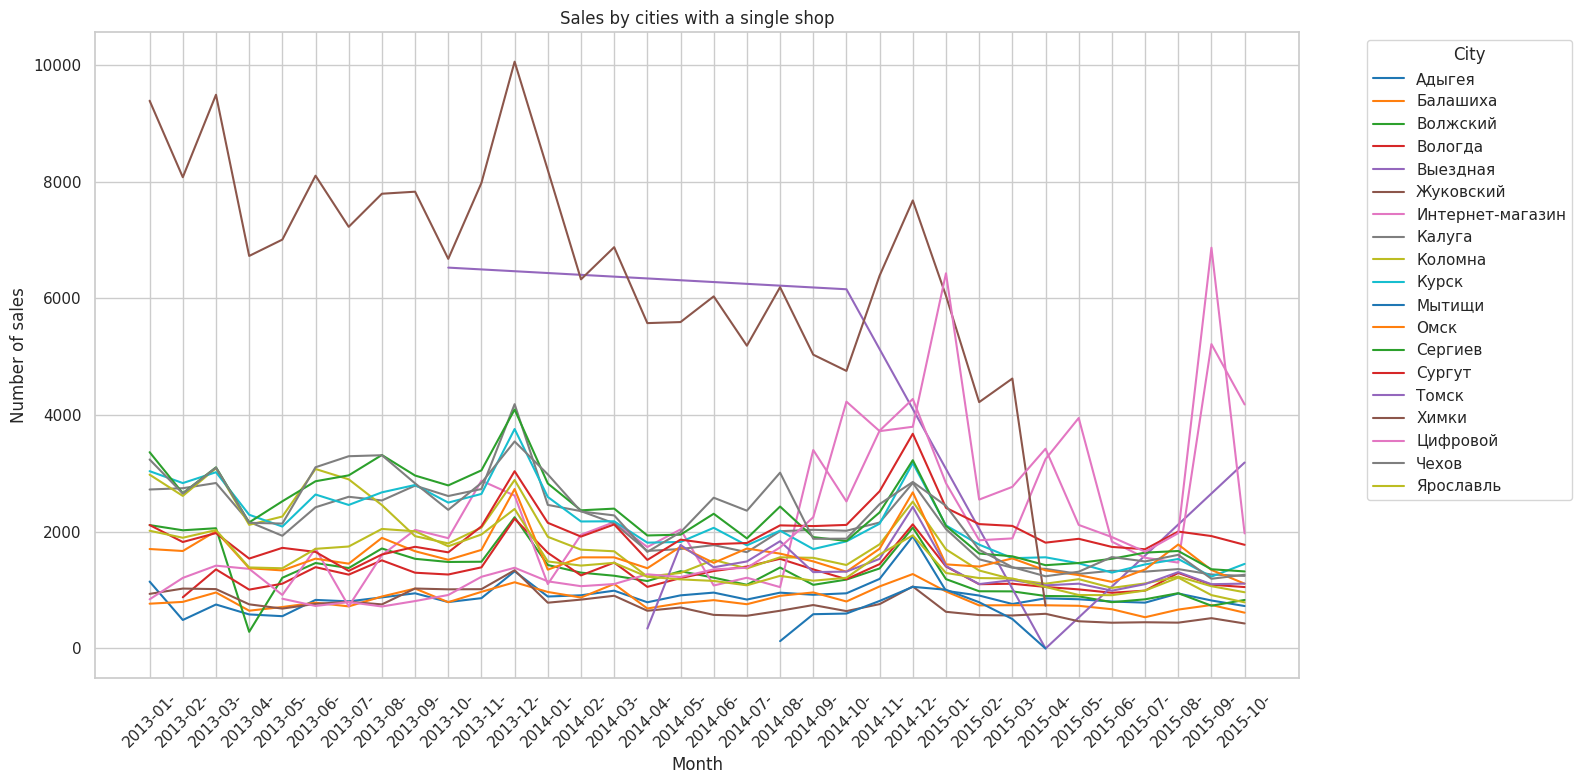

In [ ]:
# Cities with a single shop
single_shop_cities = city_shop_counts[city_shop_counts['shop_count'] == 1]['city'].tolist()

# Shops in those cities
single_shops = shop_counts[shop_counts['city'].isin(single_shop_cities)]

# Data filtering
single_city_sales = train[train['shop_id'].isin(single_shops['shop_id'])].copy()

# Grouping: monthly sales by city
sales_by_city = (
    single_city_sales
    .groupby(['city', 'year_month'])['item_cnt_day']
    .sum()
    .reset_index()
    .rename(columns={'item_cnt_day': 'total_sales'})
)

# Visualization
plt.figure(figsize=(16, 8))
sns.lineplot(data=sales_by_city, x='year_month', y='total_sales', hue='city', palette='tab10')
plt.title('Sales by cities with a single shop')
plt.ylabel('Number of sales')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend(title='City', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

- Cities with a single shop behave differently: most show stable sales, while some experience sharp spikes, especially during holiday periods.
- Khimki and Tomsk showed excellent sales performance in 2013, but sales dropped significantly afterward.

## Aggregation

In [ ]:
# Check whether shop_id–item_id pairs from test appeared in train
valid_pairs = test.merge(train[['shop_id', 'item_id']], on=['shop_id', 'item_id'], how='left', indicator=True)
inconsistent_pairs = valid_pairs[valid_pairs['_merge'] == 'left_only']
print(f"Percentage of id pairs not found in train: {inconsistent_pairs.shape[0]/test.shape[0]}")

Percentage of id pairs not found in train: 0.479593837535014


48% (почти половина) пар shop_id–item_id из test не 48% (nearly half) of the shop_id–item_id pairs from the test set were not present in historical sales data (train). It is necessary to enrich the train dataset with this information.

In [ ]:
# Aggregation by month
train_grouped = train.groupby(['date_block_num', 'shop_id', 'item_id'], as_index=False).agg({
    'item_cnt_day':'sum'
})
train_grouped.rename(columns={'item_cnt_day':'item_cnt_month'}, inplace=True)

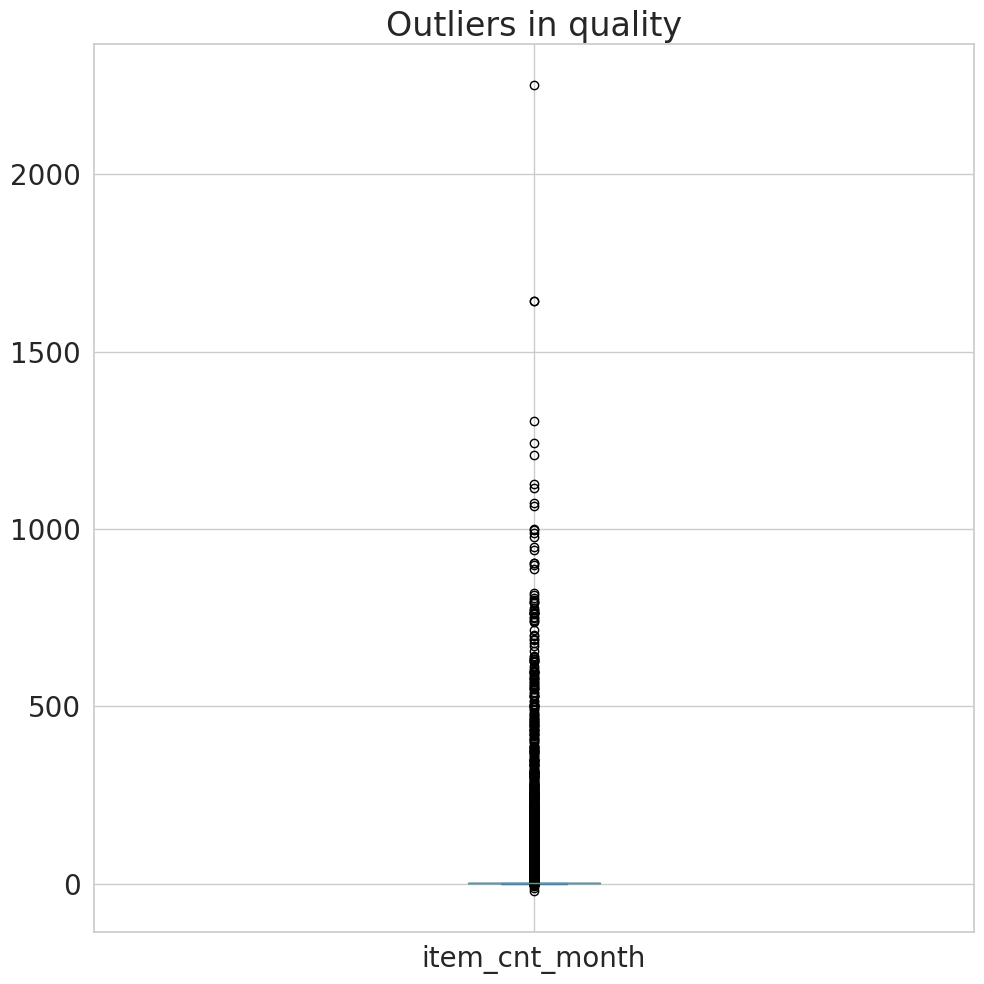

In [ ]:
# Plotting boxplot
ax = train_grouped["item_cnt_month"].plot(kind="box", subplots=True, figsize=(10, 10), fontsize=20)
plt.title("Outliers in quality", fontsize=24, x=0.5)
plt.tight_layout()

In [ ]:
def get_bounds(data, column):
    q25 = data[column].quantile(0.25) # Рассчёт интерквартильного размаха
    q75 = data[column].quantile(0.75)
    iqr = q75 - q25
    bound = (q25 - iqr * 1.5, q75 + iqr * 1.5)
    out_of_bound = ( data[column] > bound[1]) | ( data[column] < bound[0])
    anom_count = data[column][ out_of_bound ].count()

    print("\033[1m", column, "\033[0m")
    print("Interquartile range:", bound)
    print(f"Value range: ({data[column].min()}; {data[column].max()})")
    print("Number of outliers:", anom_count)
    print("Outlier percentage in sample:", anom_count / len(data) * 100, '\n')

    return [bound[0], bound[1], out_of_bound]

In [ ]:
outliars = get_bounds(train_grouped, "item_cnt_month")

 item_cnt_month 
Interquartile range: (np.float64(-0.5), np.float64(3.5))
Value range: (-22; 2253)
Number of outliers: 178987
Outlier percentage in sample: 11.123264038858434 



The interquartile range includes only one value, making it unsuitable for thresholding. We manually capped the feature at 600 units, where point density significantly increases, and excluded values below 0 to remove product returns from the predictive scope.

In [ ]:
# Exclude values af target feature
train_grouped['item_cnt_month'] = train_grouped['item_cnt_month'].clip(0,600)

In [ ]:
def create_full_train(data):
    # Generate full matrix shop_id × item_id × date_block_num (=year+month)
    grid = []

    for block_num in data['date_block_num'].unique():
      unique_shops = data.loc[data['date_block_num'] == block_num, 'shop_id'].unique()
      unique_items = data.loc[data['date_block_num'] == block_num, 'item_id'].unique()
      grid.append(np.array(list(product([block_num], unique_shops, unique_items)), dtype='int32'))

    grid = pd.DataFrame(np.vstack(grid), columns=['date_block_num', 'shop_id', 'item_id'])

    final_grid = pd.merge(grid, train_grouped, on=['date_block_num', 'shop_id', 'item_id'], how='left')

    final_grid['item_cnt_month'] = final_grid['item_cnt_month'].fillna(0).astype(np.int32)

    final_grid['item_cnt_month'] = final_grid['item_cnt_month'].clip(0,600)
    return final_grid

In [ ]:
full_train = create_full_train(train)

In [ ]:
# Add month and year
full_train['month'] = (full_train['date_block_num'] % 12) + 1
full_train['year'] = (full_train['date_block_num'] // 12) + 2013

In [ ]:
# Statistics
descr_features(full_train)

,data_type,meaning,n_NaN,%NaN,nunique,count,mean,std,min,25%,50%,75%,max
date_block_num,int32,"Порядковый номер месяца, используемый для удоб...",0,0.0,34,10913804.0,15.0,10.0,0.0,7.0,14.0,23.0,33.0
item_cnt_month,int32,new,0,0.0,384,10913804.0,0.0,3.0,0.0,0.0,0.0,0.0,600.0
month,int64,new,0,0.0,12,10913804.0,6.0,3.0,1.0,3.0,6.0,9.0,12.0
year,int64,new,0,0.0,3,10913804.0,2014.0,1.0,2013.0,2013.0,2014.0,2014.0,2015.0


In [ ]:
# Save full_train to a file
full_train.to_csv("/content/drive/MyDrive/ds-practice/data/full_train.csv", index=False)

## Conclusion

1. A clear downward trend in monthly sales is observed throughout the dataset, suggesting declining overall demand or saturation effects.
2. Data for 2015 includes only 10 months (January to October), which should be considered when interpreting year-over-year trends.
3. Moscow is the undisputed leader in both revenue and store count. Khimki and Yakutsk also show consistently strong performance.
4. Mytishchi is the least profitable city, warranting further investigation into store performance and local demand.
5. Top-performing and mid-tier stores exhibit similar seasonal patterns, with clear peaks in December. Low-performing stores show erratic behavior, possibly due to closures or unstable operations.
6. Several product categories display strong seasonality, while others maintain steady demand. Categories with persistently low activity may need to be reconsidered or phased out.
7. 48% of shop_id–item_id pairs in the test set are not present in the training set, so I have completed train.